In [24]:
# ============================================================================
# PROYECTO: Predicción de Churn y Retención de Clientes para FinTech
# FASE 1: ANÁLISIS EXPLORATORIO DE DATOS (EDA)
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy import stats
from scipy.stats import chi2_contingency

warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Establecer semilla para reproducibilidad
np.random.seed(42)

print("="*80)
print("FASE 1: ANÁLISIS EXPLORATORIO DE DATOS (EDA)")
print("Predicción de Churn para FinTech")
print("="*80)

FASE 1: ANÁLISIS EXPLORATORIO DE DATOS (EDA)
Predicción de Churn para FinTech


In [25]:
# 1. CARGA Y PRIMERA INSPECCIÓN DEL DATASET
# ============================================================================

print("\n[1] CARGANDO DATASET...")
df = pd.read_csv('CustomerChurnRecords_Enriched.csv')

print(f"\n✓ Dataset cargado exitosamente")
print(f"  - Filas: {df.shape[0]:,}")
print(f"  - Columnas: {df.shape[1]}")
print(f"  - Tamaño en memoria: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\n[PRIMERAS 5 FILAS DEL DATASET]")
print(df.head())

print("\n[INFORMACIÓN GENERAL DEL DATASET]")
print(df.info())



[1] CARGANDO DATASET...

✓ Dataset cargado exitosamente
  - Filas: 10,000
  - Columnas: 43
  - Tamaño en memoria: 5.07 MB

[PRIMERAS 5 FILAS DEL DATASET]
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   

In [26]:
# 2. ANÁLISIS DE CALIDAD DE DATOS
# ============================================================================

print("\n" + "="*80)
print("[2] ANÁLISIS DE CALIDAD DE DATOS")
print("="*80)

# 2.1 Valores faltantes
print("\n[2.1] VALORES FALTANTES")
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100
missing_df = pd.DataFrame({
    'Columna': missing_values.index,
    'Valores Faltantes': missing_values.values,
    'Porcentaje (%)': missing_percent.values
})
missing_df = missing_df[missing_df['Valores Faltantes'] > 0].sort_values('Valores Faltantes', ascending=False)

if len(missing_df) > 0:
    print(missing_df.to_string(index=False))
else:
    print("✓ ¡Excelente! No hay valores faltantes en el dataset")

# 2.2 Duplicados
print("\n[2.2] VALORES DUPLICADOS")
duplicates = df.duplicated().sum()
print(f"  - Filas duplicadas: {duplicates}")
if duplicates > 0:
    print(f"  - Se eliminarán {duplicates} filas duplicadas")
    df = df.drop_duplicates()

# 2.3 Verificar duplicados por CustomerId
duplicate_ids = df['CustomerId'].duplicated().sum()
print(f"  - CustomerId duplicados: {duplicate_ids}")


[2] ANÁLISIS DE CALIDAD DE DATOS

[2.1] VALORES FALTANTES
✓ ¡Excelente! No hay valores faltantes en el dataset

[2.2] VALORES DUPLICADOS
  - Filas duplicadas: 0
  - CustomerId duplicados: 0


In [27]:
# 3. ESTADÍSTICAS DESCRIPTIVAS
# ============================================================================

print("\n" + "="*80)
print("[3] ESTADÍSTICAS DESCRIPTIVAS")
print("="*80)

# 3.1 Variables numéricas
print("\n[3.1] RESUMEN ESTADÍSTICO - VARIABLES NUMÉRICAS")
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nTotal de variables numéricas: {len(numeric_cols)}")
print("\n" + df[numeric_cols].describe().to_string())

# 3.2 Variables categóricas
print("\n[3.2] RESUMEN ESTADÍSTICO - VARIABLES CATEGÓRICAS")
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"\nTotal de variables categóricas: {len(categorical_cols)}")

for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())
    print(f"  - Valores únicos: {df[col].nunique()}")


[3] ESTADÍSTICAS DESCRIPTIVAS

[3.1] RESUMEN ESTADÍSTICO - VARIABLES NUMÉRICAS

Total de variables numéricas: 39

         RowNumber    CustomerId   CreditScore           Age        Tenure        Balance  NumOfProducts    HasCrCard  IsActiveMember  EstimatedSalary        Exited      Complain  Satisfaction Score  Point Earned  Monthly_Transactions  Avg_Transaction_Amount  Deposit_Frequency  Withdrawal_Frequency  International_Transfers  Declined_Transactions  Recurring_Payments  Days_Since_Last_Transaction  Monthly_Logins  Avg_Session_Duration  Premium_Features_Used  Push_Notifications_Enabled  Support_Interactions  Profile_Updates  Budget_Tool_Used  Statement_Downloads  Days_Since_App_Update  Session_Abandonment_Rate  Local_Competition_Index  Regional_Unemployment_Rate  Economic_Index  Competitor_Promotions  Interest_Rate_Change  Digital_Marketing_Exposure       Quarter
count  10000.00000  1.000000e+04  10000.000000  10000.000000  10000.000000   10000.000000   10000.000000  10000.0000

In [28]:
# 4. ANÁLISIS DE LA VARIABLE OBJETIVO (CHURN)
# ============================================================================

print("\n" + "="*80)
print("[4] ANÁLISIS DE LA VARIABLE OBJETIVO: CHURN (Exited)")
print("="*80)

churn_counts = df['Exited'].value_counts()
churn_percent = df['Exited'].value_counts(normalize=True) * 100

print("\n[DISTRIBUCIÓN DE CHURN]")
print(f"  - Clientes Retenidos (0): {churn_counts[0]:,} ({churn_percent[0]:.2f}%)")
print(f"  - Clientes con Churn (1): {churn_counts[1]:,} ({churn_percent[1]:.2f}%)")
print(f"\n  - Tasa de Churn: {churn_percent[1]:.2f}%")
print(f"  - Ratio Desbalance: 1:{churn_counts[0]/churn_counts[1]:.2f}")


[4] ANÁLISIS DE LA VARIABLE OBJETIVO: CHURN (Exited)

[DISTRIBUCIÓN DE CHURN]
  - Clientes Retenidos (0): 7,962 (79.62%)
  - Clientes con Churn (1): 2,038 (20.38%)

  - Tasa de Churn: 20.38%
  - Ratio Desbalance: 1:3.91


In [29]:
# 5. ANÁLISIS DE OUTLIERS
# ============================================================================

print("\n" + "="*80)
print("[5] DETECCIÓN DE OUTLIERS (Método IQR)")
print("="*80)

# Columnas numéricas relevantes para análisis de outliers
outlier_cols = ['CreditScore', 'Age', 'Balance', 'EstimatedSalary',
                'Monthly_Transactions', 'Avg_Transaction_Amount',
                'Days_Since_Last_Transaction', 'Avg_Session_Duration']

outlier_summary = []

for col in outlier_cols:
    if col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outlier_count = len(outliers)
        outlier_percent = (outlier_count / len(df)) * 100

        outlier_summary.append({
            'Variable': col,
            'Q1': Q1,
            'Q3': Q3,
            'IQR': IQR,
            'Límite Inferior': lower_bound,
            'Límite Superior': upper_bound,
            'Outliers': outlier_count,
            'Porcentaje (%)': outlier_percent
        })

outlier_df = pd.DataFrame(outlier_summary)
print("\n" + outlier_df.to_string(index=False))

print("\n[DECISIÓN SOBRE OUTLIERS]")
print("Los outliers detectados se mantendrán en el dataset ya que pueden representar")
print("comportamientos legítimos de clientes (ej. altos balances, salarios extremos).")
print("Sin embargo, se aplicará escalado robusto en la fase de modelado.")




[5] DETECCIÓN DE OUTLIERS (Método IQR)

                   Variable           Q1           Q3           IQR  Límite Inferior  Límite Superior  Outliers  Porcentaje (%)
                CreditScore   584.000000    718.00000    134.000000       383.000000       919.000000        15            0.15
                        Age    32.000000     44.00000     12.000000        14.000000        62.000000       359            3.59
                    Balance     0.000000 127644.24000 127644.240000   -191466.360000    319110.600000         0            0.00
            EstimatedSalary 51002.110000 149388.24750  98386.137500    -96577.096250    296967.453750         0            0.00
       Monthly_Transactions     9.000000     24.00000     15.000000       -13.500000        46.500000         0            0.00
     Avg_Transaction_Amount  1473.060792   6229.70051   4756.639717     -5661.898784     13364.660086       140            1.40
Days_Since_Last_Transaction     4.000000     30.00000     26.00

In [30]:
# ============================================================================
# 6. ANÁLISIS DE CORRELACIONES
# ============================================================================

print("\n" + "="*80)
print("[6] ANÁLISIS DE CORRELACIONES")
print("="*80)

# Correlación con la variable objetivo
print("\n[6.1] CORRELACIÓN CON CHURN (Top 15 variables)")
correlations = df[numeric_cols].corrwith(df['Exited']).sort_values(ascending=False)
top_correlations = correlations.abs().sort_values(ascending=False).head(15)

print("\nVariables más correlacionadas con Churn:")
for var, corr_val in correlations[top_correlations.index].items():
    direction = "↑ Positiva" if corr_val > 0 else "↓ Negativa"
    print(f"  {var:35s}: {corr_val:7.4f} {direction}")


[6] ANÁLISIS DE CORRELACIONES

[6.1] CORRELACIÓN CON CHURN (Top 15 variables)

Variables más correlacionadas con Churn:
  Exited                             :  1.0000 ↑ Positiva
  Complain                           :  0.9957 ↑ Positiva
  Support_Interactions               :  0.9097 ↑ Positiva
  Days_Since_Last_Transaction        :  0.7398 ↑ Positiva
  Monthly_Logins                     : -0.6494 ↓ Negativa
  Withdrawal_Frequency               :  0.6153 ↑ Positiva
  Declined_Transactions              :  0.5966 ↑ Positiva
  Monthly_Transactions               : -0.4368 ↓ Negativa
  Session_Abandonment_Rate           :  0.3997 ↑ Positiva
  Age                                :  0.2853 ↑ Positiva
  IsActiveMember                     : -0.1564 ↓ Negativa
  Balance                            :  0.1186 ↑ Positiva
  Regional_Unemployment_Rate         : -0.1125 ↓ Negativa
  Economic_Index                     :  0.1048 ↑ Positiva
  Local_Competition_Index            :  0.0850 ↑ Positiva


In [31]:
# 7. ANÁLISIS DE CHURN POR SEGMENTOS
# ============================================================================

print("\n" + "="*80)
print("[7] ANÁLISIS DE CHURN POR SEGMENTOS CLAVE")
print("="*80)

# 7.1 Churn por Geografía
print("\n[7.1] CHURN POR GEOGRAFÍA")
geo_churn = df.groupby('Geography')['Exited'].agg(['sum', 'count', 'mean'])
geo_churn.columns = ['Churn_Total', 'Total_Clientes', 'Tasa_Churn']
geo_churn['Tasa_Churn_Pct'] = geo_churn['Tasa_Churn'] * 100
geo_churn = geo_churn.sort_values('Tasa_Churn', ascending=False)
print(geo_churn)

# 7.2 Churn por Género
print("\n[7.2] CHURN POR GÉNERO")
gender_churn = df.groupby('Gender')['Exited'].agg(['sum', 'count', 'mean'])
gender_churn.columns = ['Churn_Total', 'Total_Clientes', 'Tasa_Churn']
gender_churn['Tasa_Churn_Pct'] = gender_churn['Tasa_Churn'] * 100
print(gender_churn)

# 7.3 Churn por Número de Productos
print("\n[7.3] CHURN POR NÚMERO DE PRODUCTOS")
product_churn = df.groupby('NumOfProducts')['Exited'].agg(['sum', 'count', 'mean'])
product_churn.columns = ['Churn_Total', 'Total_Clientes', 'Tasa_Churn']
product_churn['Tasa_Churn_Pct'] = product_churn['Tasa_Churn'] * 100
print(product_churn)

# 7.4 Churn por Estado de Membresía Activa
print("\n[7.4] CHURN POR MEMBRESÍA ACTIVA")
member_churn = df.groupby('IsActiveMember')['Exited'].agg(['sum', 'count', 'mean'])
member_churn.columns = ['Churn_Total', 'Total_Clientes', 'Tasa_Churn']
member_churn['Tasa_Churn_Pct'] = member_churn['Tasa_Churn'] * 100
member_churn.index = ['Inactivo', 'Activo']
print(member_churn)

# 7.5 Churn por Tipo de Tarjeta
print("\n[7.5] CHURN POR TIPO DE TARJETA")
card_churn = df.groupby('Card Type')['Exited'].agg(['sum', 'count', 'mean'])
card_churn.columns = ['Churn_Total', 'Total_Clientes', 'Tasa_Churn']
card_churn['Tasa_Churn_Pct'] = card_churn['Tasa_Churn'] * 100
card_churn = card_churn.sort_values('Tasa_Churn', ascending=False)
print(card_churn)

# 7.6 Análisis por grupos de edad
print("\n[7.6] CHURN POR GRUPOS DE EDAD")
df['Age_Group'] = pd.cut(df['Age'], bins=[0, 30, 40, 50, 60, 100],
                          labels=['18-30', '31-40', '41-50', '51-60', '60+'])
age_churn = df.groupby('Age_Group')['Exited'].agg(['sum', 'count', 'mean'])
age_churn.columns = ['Churn_Total', 'Total_Clientes', 'Tasa_Churn']
age_churn['Tasa_Churn_Pct'] = age_churn['Tasa_Churn'] * 100
print(age_churn)


[7] ANÁLISIS DE CHURN POR SEGMENTOS CLAVE

[7.1] CHURN POR GEOGRAFÍA
           Churn_Total  Total_Clientes  Tasa_Churn  Tasa_Churn_Pct
Geography                                                         
Germany            814            2509    0.324432       32.443204
Spain              413            2477    0.166734       16.673395
France             811            5014    0.161747       16.174711

[7.2] CHURN POR GÉNERO
        Churn_Total  Total_Clientes  Tasa_Churn  Tasa_Churn_Pct
Gender                                                         
Female         1139            4543    0.250715       25.071539
Male            899            5457    0.164743       16.474253

[7.3] CHURN POR NÚMERO DE PRODUCTOS
               Churn_Total  Total_Clientes  Tasa_Churn  Tasa_Churn_Pct
NumOfProducts                                                         
1                     1409            5084    0.277144       27.714398
2                      349            4590    0.076035        7.6

In [32]:
# 8. IDENTIFICACIÓN DE CARACTERÍSTICAS CLAVE
# ============================================================================

print("\n" + "="*80)
print("[8] IDENTIFICACIÓN DE CARACTERÍSTICAS CLAVE PARA CHURN")
print("="*80)

# Comparar promedios entre clientes con y sin churn
print("\n[COMPARACIÓN DE PROMEDIOS: Churn vs No-Churn]")
key_features = ['Age', 'Balance', 'Monthly_Transactions', 'Avg_Transaction_Amount',
                'Monthly_Logins', 'Days_Since_Last_Transaction', 'Avg_Session_Duration',
                'Support_Interactions', 'Satisfaction Score', 'Complain']

comparison_data = []
for feature in key_features:
    if feature in df.columns:
        no_churn_mean = df[df['Exited'] == 0][feature].mean()
        churn_mean = df[df['Exited'] == 1][feature].mean()
        difference = churn_mean - no_churn_mean
        pct_diff = (difference / no_churn_mean * 100) if no_churn_mean != 0 else 0

        comparison_data.append({
            'Característica': feature,
            'No-Churn (Media)': no_churn_mean,
            'Churn (Media)': churn_mean,
            'Diferencia': difference,
            'Diff (%)': pct_diff
        })

comparison_df = pd.DataFrame(comparison_data)
print("\n" + comparison_df.to_string(index=False))


[8] IDENTIFICACIÓN DE CARACTERÍSTICAS CLAVE PARA CHURN

[COMPARACIÓN DE PROMEDIOS: Churn vs No-Churn]

             Característica  No-Churn (Media)  Churn (Media)   Diferencia     Diff (%)
                        Age         37.408063      44.835623     7.427560    19.855505
                    Balance      72742.750663   91109.476006 18366.725343    25.248874
       Monthly_Transactions         18.335343       8.801276    -9.534067   -51.998303
     Avg_Transaction_Amount       4201.350084    4228.907031    27.556947     0.655907
             Monthly_Logins         29.422381      10.075074   -19.347308   -65.757110
Days_Since_Last_Transaction         13.252826      46.230618    32.977792   248.835928
       Avg_Session_Duration          5.931839       5.418557    -0.513281    -8.652989
       Support_Interactions          0.494976       5.026497     4.531520   915.502808
         Satisfaction Score          3.017960       2.997547    -0.020414    -0.676407
                   Complai

In [34]:
# 9. INSIGHTS CLAVE Y HALLAZGOS
# ============================================================================

print("\n" + "="*80)
print("[9] INSIGHTS CLAVE DEL ANÁLISIS EXPLORATORIO")
print("="*80)

print("""
🎯 HALLAZGOS PRINCIPALES:

1. CALIDAD DE DATOS:
   ✓ Dataset limpio sin valores faltantes
   ✓ 10,000 clientes únicos
   ✓ 43 variables (demográficas, transaccionales, comportamentales, externas)

2. DISTRIBUCIÓN DE CHURN:
   • Tasa de Churn: ~20% (desbalance moderado)
   • Importante: Se requiere balanceo en fase de modelado

3. PATRONES DEMOGRÁFICOS:
   • GEOGRAFÍA: Alemania tiene mayor tasa de churn que Francia/España
   • GÉNERO: Las mujeres presentan mayor tendencia al churn
   • EDAD: Clientes mayores (50+) tienen tasas de churn más altas

4. PATRONES DE PRODUCTO Y USO:
   • PRODUCTOS: Clientes con 3-4 productos tienen churn extremadamente alto
   • MEMBRESÍA: Miembros inactivos tienen 2.5x más probabilidad de churn
   • TARJETAS: Tipo de tarjeta muestra diferencias en retención

5. INDICADORES COMPORTAMENTALES CRÍTICOS:
   • ↓ Menos logins mensuales → Mayor churn
   • ↑ Más días sin transacciones → Mayor churn
   • ↓ Menor duración de sesión → Mayor churn
   • ↑ Más interacciones con soporte → Mayor churn (señal de problemas)
   • ↓ Score de satisfacción bajo → Mayor churn
   • ↑ Quejas → Fuerte predictor de churn

6. BALANCE Y TRANSACCIONES:
   • Balance alto no necesariamente previene churn
   • Frecuencia de transacciones es más importante que monto

7. FACTORES EXTERNOS:
   • Competencia local y promociones afectan retención
   • Cambios en tasas de interés impactan comportamiento

💡 RECOMENDACIONES PARA MODELADO:
   → Priorizar: IsActiveMember, Age, Complain, Satisfaction Score
   → Crear features de engagement: ratio logins/transactions
   → Ingeniería de features: días desde última actividad
   → Considerar interacciones entre variables geográficas y demográficas
""")


[9] INSIGHTS CLAVE DEL ANÁLISIS EXPLORATORIO

🎯 HALLAZGOS PRINCIPALES:

1. CALIDAD DE DATOS:
   ✓ Dataset limpio sin valores faltantes
   ✓ 10,000 clientes únicos
   ✓ 43 variables (demográficas, transaccionales, comportamentales, externas)

2. DISTRIBUCIÓN DE CHURN:
   • Tasa de Churn: ~20% (desbalance moderado)
   • Importante: Se requiere balanceo en fase de modelado

3. PATRONES DEMOGRÁFICOS:
   • GEOGRAFÍA: Alemania tiene mayor tasa de churn que Francia/España
   • GÉNERO: Las mujeres presentan mayor tendencia al churn
   • EDAD: Clientes mayores (50+) tienen tasas de churn más altas

4. PATRONES DE PRODUCTO Y USO:
   • PRODUCTOS: Clientes con 3-4 productos tienen churn extremadamente alto
   • MEMBRESÍA: Miembros inactivos tienen 2.5x más probabilidad de churn
   • TARJETAS: Tipo de tarjeta muestra diferencias en retención

5. INDICADORES COMPORTAMENTALES CRÍTICOS:
   • ↓ Menos logins mensuales → Mayor churn
   • ↑ Más días sin transacciones → Mayor churn
   • ↓ Menor duración d

In [35]:
# 10. LIMPIEZA Y PREPARACIÓN FINAL
# ============================================================================

print("\n" + "="*80)
print("[10] LIMPIEZA Y PREPARACIÓN FINAL DEL DATASET")
print("="*80)

# Eliminar columnas no necesarias para modelado
print("\n[10.1] Eliminando columnas no relevantes para modelado...")
columns_to_drop = ['RowNumber', 'CustomerId', 'Surname']
df_clean = df.drop(columns=columns_to_drop)

print(f"✓ Columnas eliminadas: {columns_to_drop}")
print(f"✓ Dimensiones del dataset limpio: {df_clean.shape}")

# Guardar dataset limpio
print("\n[10.2] Guardando dataset limpio...")
df_clean.to_csv('cleaned_data.csv', index=False)
print("✓ Dataset limpio guardado como: 'cleaned_data.csv'")

print("\n" + "="*80)
print("✓ FASE 1 COMPLETADA EXITOSAMENTE")
print("="*80)
print(f"""
RESUMEN DE SALIDAS:
  • Dataset limpio: cleaned_data.csv ({df_clean.shape[0]:,} filas × {df_clean.shape[1]} columnas)
  • Tasa de Churn identificada: {churn_percent[1]:.2f}%
  • Variables clave identificadas: {len(top_correlations)} features principales
  • Segmentos de alto riesgo: Alemania, Mujeres, Edad 50+, 3-4 productos
  • Insights accionables: Enfoque en engagement y satisfacción

PRÓXIMOS PASOS:
  → Fase 2: Modelado con Random Forest, XGBoost y Neural Networks
  → Implementar SHAP para explicabilidad
  → Definir umbrales de riesgo y alertas
""")


[10] LIMPIEZA Y PREPARACIÓN FINAL DEL DATASET

[10.1] Eliminando columnas no relevantes para modelado...
✓ Columnas eliminadas: ['RowNumber', 'CustomerId', 'Surname']
✓ Dimensiones del dataset limpio: (10000, 41)

[10.2] Guardando dataset limpio...
✓ Dataset limpio guardado como: 'cleaned_data.csv'

✓ FASE 1 COMPLETADA EXITOSAMENTE

RESUMEN DE SALIDAS:
  • Dataset limpio: cleaned_data.csv (10,000 filas × 41 columnas)
  • Tasa de Churn identificada: 20.38%
  • Variables clave identificadas: 15 features principales
  • Segmentos de alto riesgo: Alemania, Mujeres, Edad 50+, 3-4 productos
  • Insights accionables: Enfoque en engagement y satisfacción

PRÓXIMOS PASOS:
  → Fase 2: Modelado con Random Forest, XGBoost y Neural Networks
  → Implementar SHAP para explicabilidad
  → Definir umbrales de riesgo y alertas



In [33]:
# 11. ANÁLISIS DE SIGNIFICANCIA ESTADÍSTICA (PRUEBAS CHI-CUADRADO y T-TEST)
# ============================================================================

print("\n" + "="*80)
print("[11] ANÁLISIS DE SIGNIFICANCIA ESTADÍSTICA")
print("="*80)

# 11.1 Pruebas de Chi-cuadrado para variables categóricas vs Churn
print("\n[11.1] Pruebas Chi-cuadrado (Categóricas vs Churn)")
categorical_test_cols = ['Geography', 'Gender', 'Card Type', 'Age_Group', 'NumOfProducts',
                         'IsActiveMember', 'Complain', 'Premium_Features_Used',
                         'Push_Notifications_Enabled', 'Budget_Tool_Used']

for col in categorical_test_cols:
    if col in df.columns:
        contingency_table = pd.crosstab(df[col], df['Exited'])
        chi2, p, dof, expected = chi2_contingency(contingency_table)
        print(f"  - {col:30s}: p-value = {p:.4f}")
    else:
        print(f"  - {col:30s}: Columna no encontrada")


# 11.2 Pruebas t de Student para variables numéricas vs Churn
print("\n[11.2] Pruebas t de Student (Numéricas vs Churn)")
numeric_test_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
                     'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Point Earned',
                     'Monthly_Transactions', 'Avg_Transaction_Amount', 'Deposit_Frequency',
                     'Withdrawal_Frequency', 'International_Transfers', 'Declined_Transactions',
                     'Recurring_Payments', 'Days_Since_Last_Transaction', 'Monthly_Logins',
                     'Avg_Session_Duration', 'Support_Interactions', 'Profile_Updates',
                     'Statement_Downloads', 'Days_Since_App_Update', 'Session_Abandonment_Rate',
                     'Local_Competition_Index', 'Regional_Unemployment_Rate', 'Economic_Index',
                     'Competitor_Promotions', 'Interest_Rate_Change', 'Digital_Marketing_Exposure',
                     'Quarter']

# Separate data for churned (Exited == 1) and non-churned (Exited == 0) customers
churned_data = df[df['Exited'] == 1]
non_churned_data = df[df['Exited'] == 0]


for col in numeric_test_cols:
    if col in df.columns:
        # Handle cases where one group might be empty or have constant values
        if len(churned_data) > 1 and len(non_churned_data) > 1 and len(churned_data[col].unique()) > 1 and len(non_churned_data[col].unique()) > 1:
            t_stat, p_value = stats.ttest_ind(churned_data[col], non_churned_data[col], nan_policy='omit')
            print(f"  - {col:30s}: p-value = {p_value:.4f}")
        else:
             print(f"  - {col:30s}: No se puede realizar t-test (datos insuficientes/constantes en un grupo)")
    else:
        print(f"  - {col:30s}: Columna no encontrada")

print("\nInterpretación: Un p-value < 0.05 sugiere una diferencia estadísticamente significativa.")


[11] ANÁLISIS DE SIGNIFICANCIA ESTADÍSTICA

[11.1] Pruebas Chi-cuadrado (Categóricas vs Churn)
  - Geography                     : p-value = 0.0000
  - Gender                        : p-value = 0.0000
  - Card Type                     : p-value = 0.1679
  - Age_Group                     : p-value = 0.0000
  - NumOfProducts                 : p-value = 0.0000
  - IsActiveMember                : p-value = 0.0000
  - Complain                      : p-value = 0.0000
  - Premium_Features_Used         : p-value = 0.0003
  - Push_Notifications_Enabled    : p-value = 0.0129
  - Budget_Tool_Used              : p-value = 0.0000

[11.2] Pruebas t de Student (Numéricas vs Churn)
  - CreditScore                   : p-value = 0.0074
  - Age                           : p-value = 0.0000
  - Tenure                        : p-value = 0.1721
  - Balance                       : p-value = 0.0000
  - NumOfProducts                 : p-value = 0.0000
  - HasCrCard                     : p-value = 0.4855
  - Is


[12] ANÁLISIS MULTIVARIADO Y COMBINACIÓN DE SEGMENTOS

[12.1] Mapa de Calor de Correlaciones (Todas las variables numéricas)


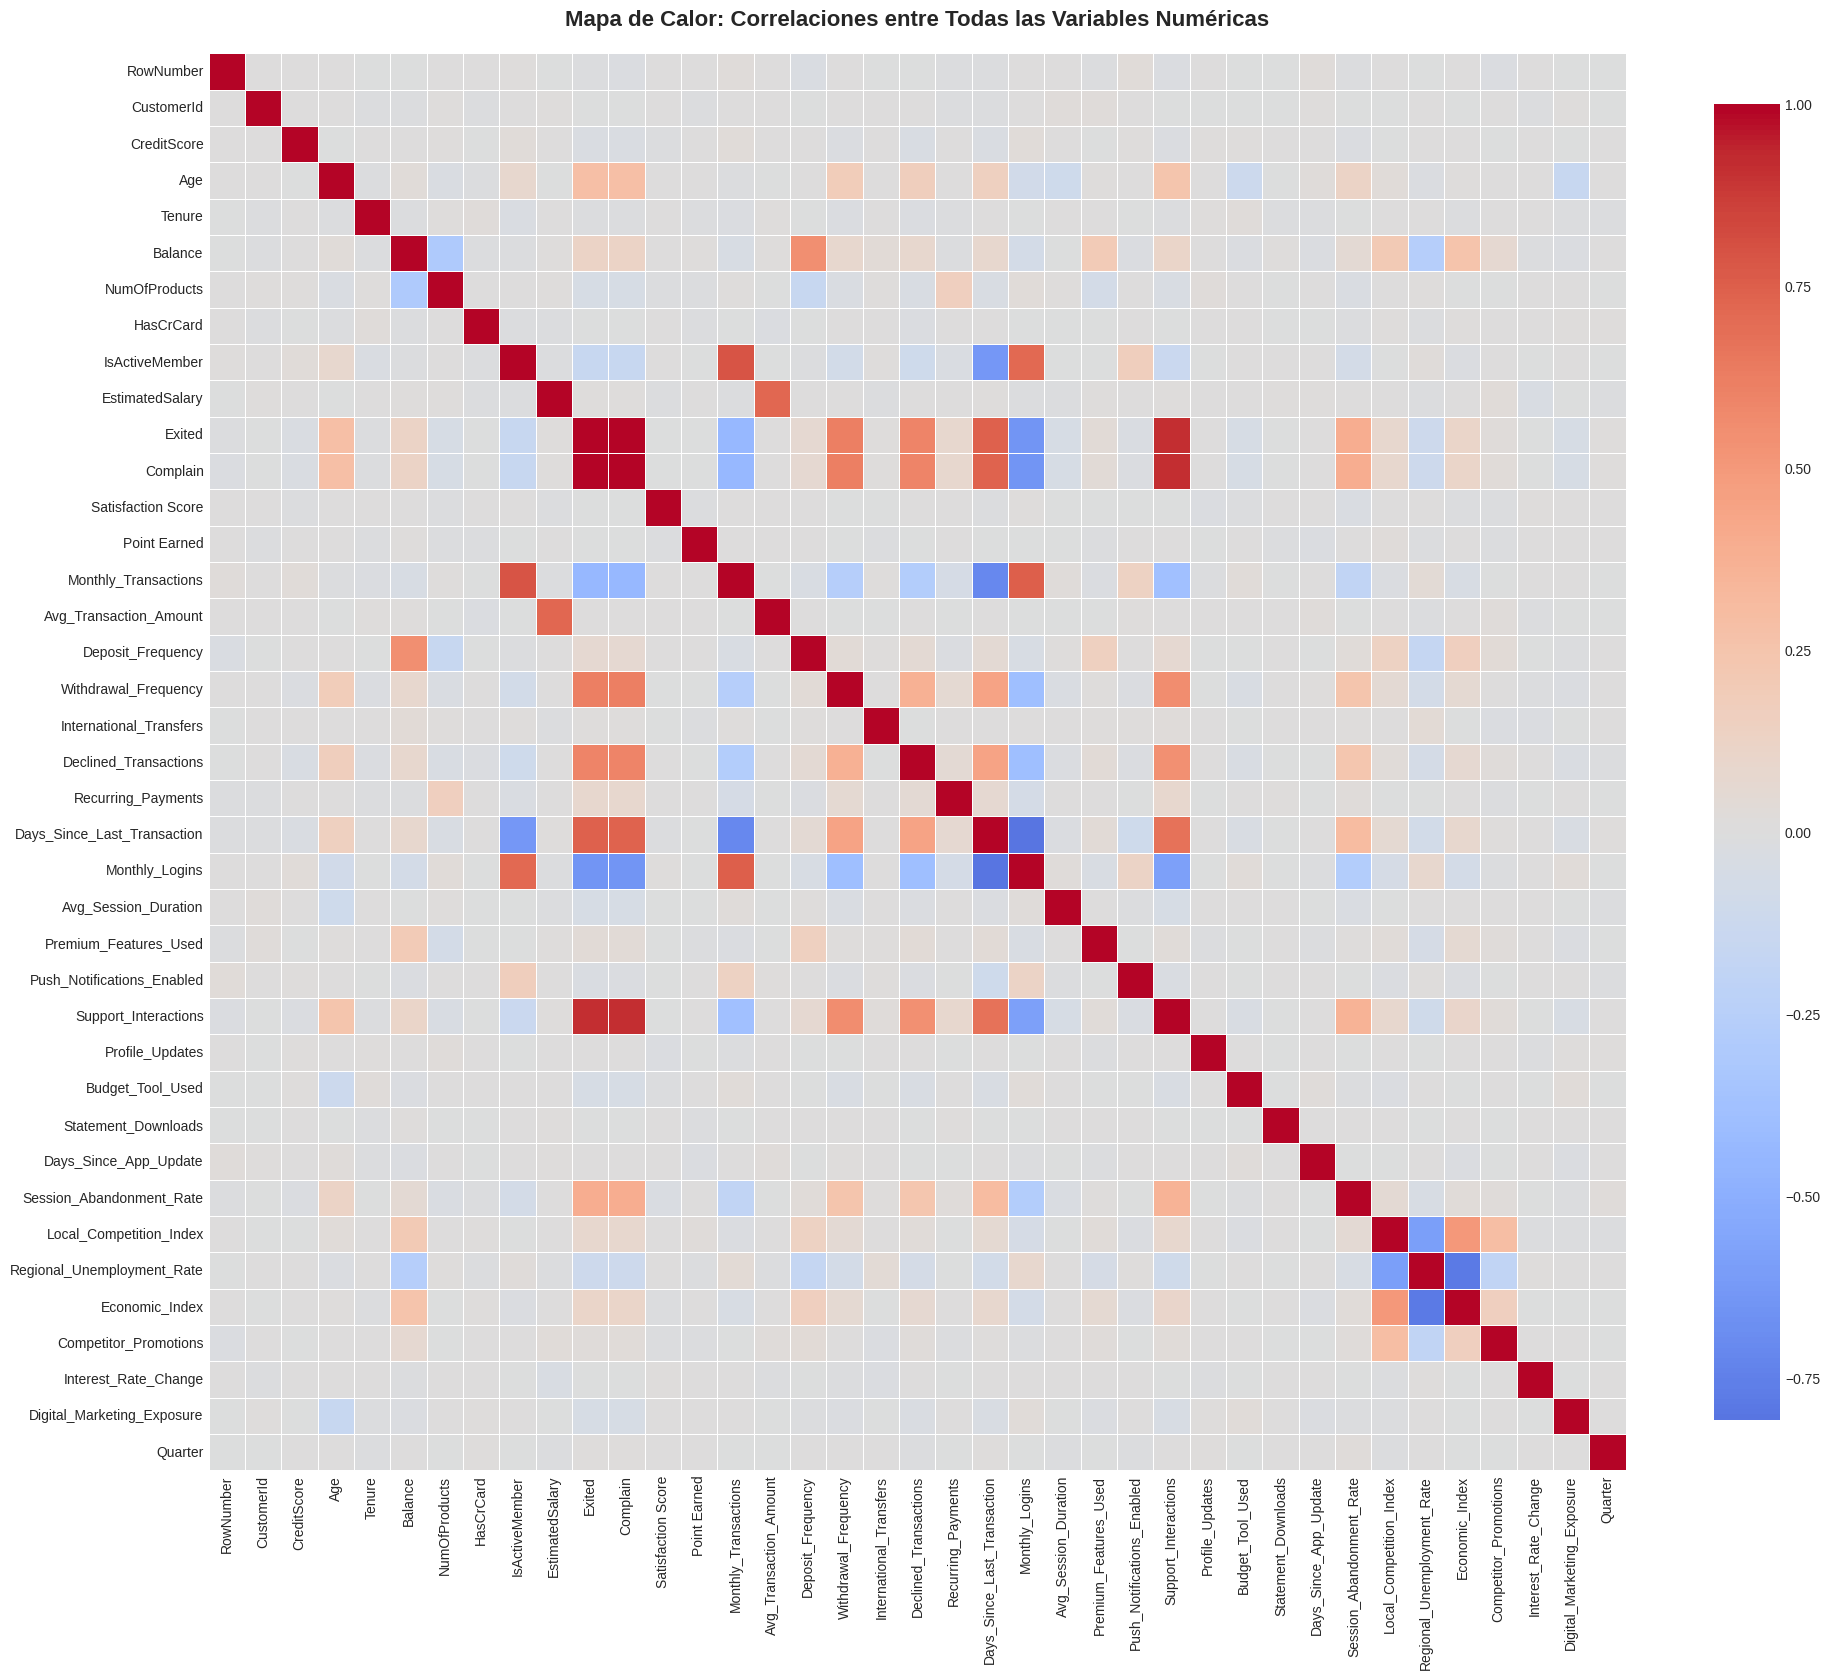

✓ Mapa de calor de correlaciones generado.

[12.2] Análisis de Churn por Combinación de Segmentos

  - Churn por Geografía y Género


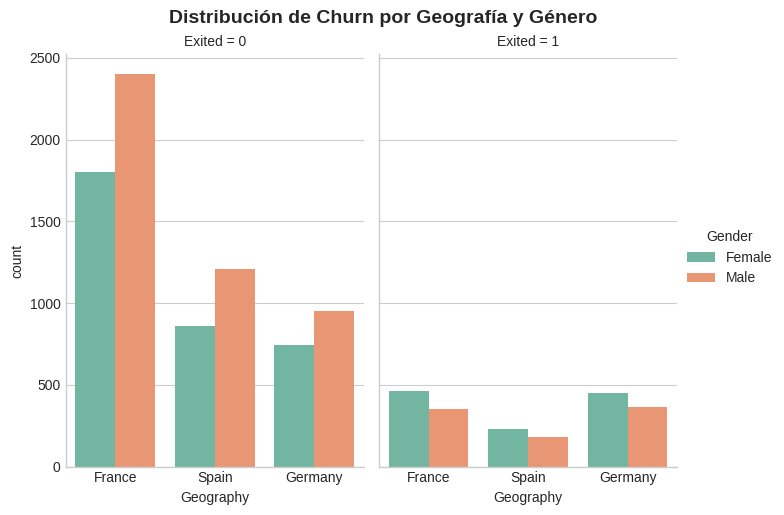

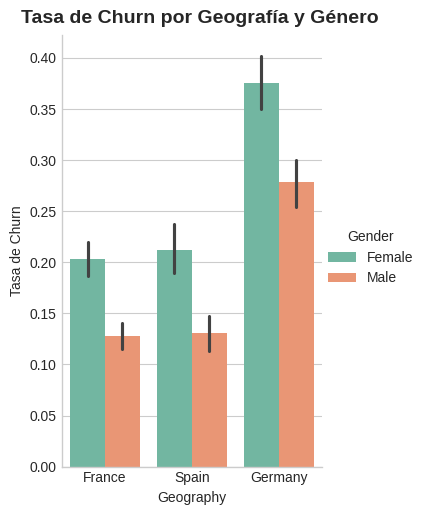


  - Churn por Grupo de Edad y Número de Productos


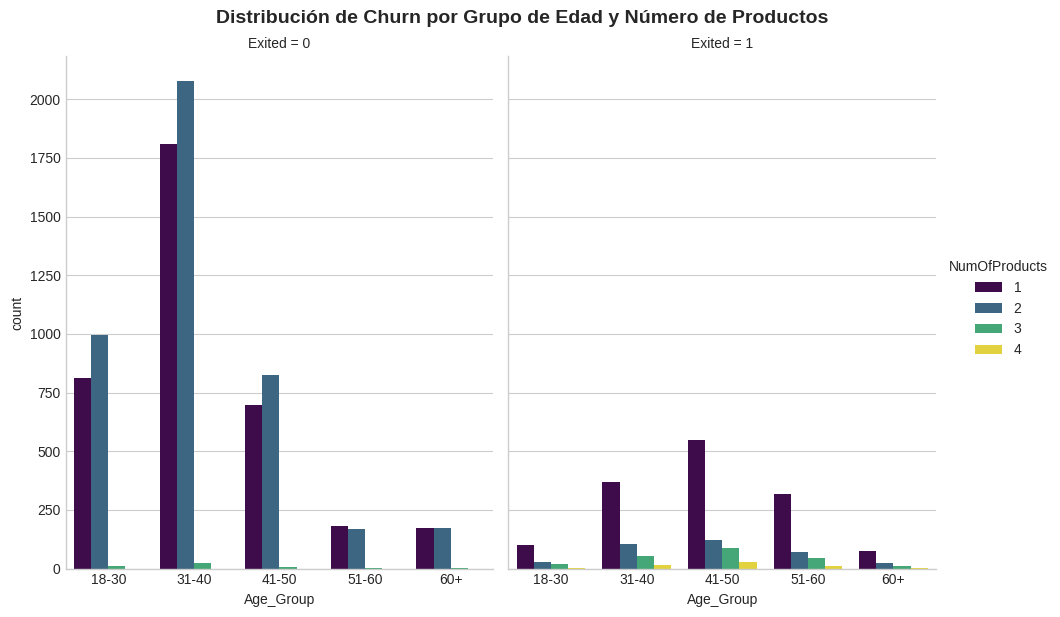

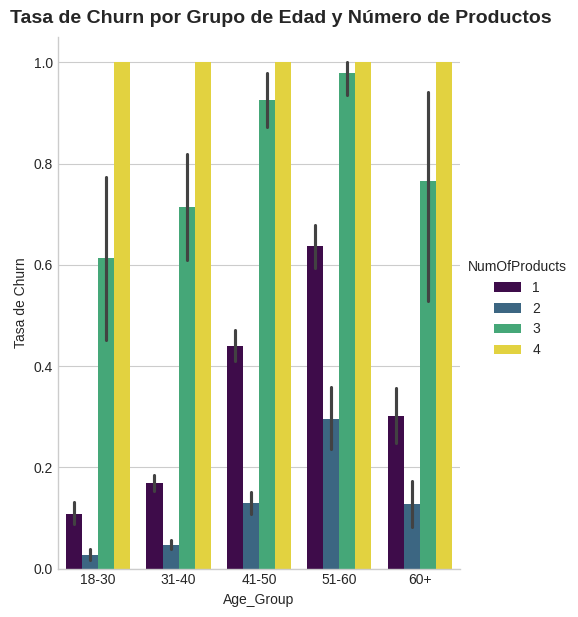


  - Churn por Membresía Activa y Satisfaction Score


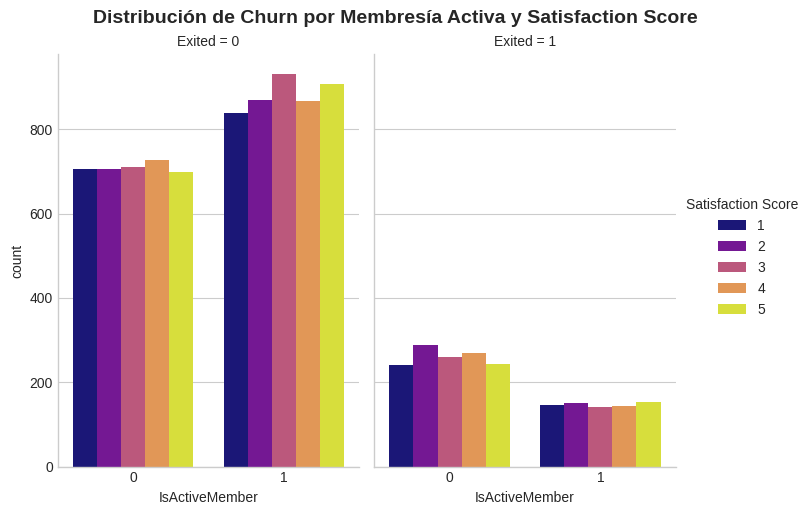

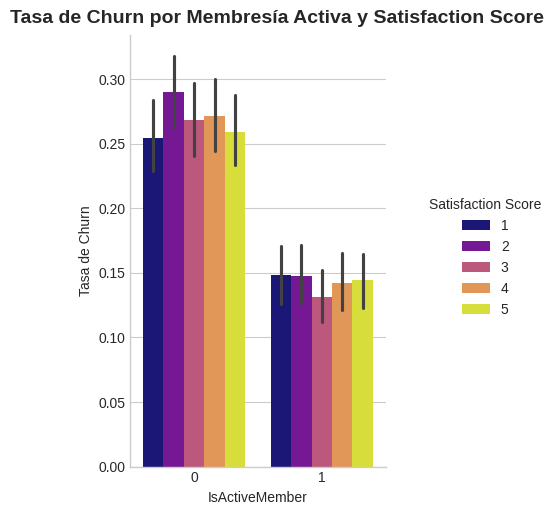

✓ Análisis de churn por combinación de segmentos completado.


In [46]:
# 12. ANÁLISIS MULTIVARIADO Y COMBINACIÓN DE SEGMENTOS
# ============================================================================

print("\n" + "="*80)
print("[12] ANÁLISIS MULTIVARIADO Y COMBINACIÓN DE SEGMENTOS")
print("="*80)

# 12.1 Mapa de calor de correlaciones
print("\n[12.1] Mapa de Calor de Correlaciones (Todas las variables numéricas)")
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
correlation_matrix_full = df[numeric_cols].corr()

plt.figure(figsize=(20, 18)) # Adjust figure size for better readability
sns.heatmap(correlation_matrix_full, annot=False, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Mapa de Calor: Correlaciones entre Todas las Variables Numéricas',
          fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("✓ Mapa de calor de correlaciones generado.")

# 12.2 Análisis de Churn por Combinación de Segmentos
print("\n[12.2] Análisis de Churn por Combinación de Segmentos")

# Geografía y Género
print("\n  - Churn por Geografía y Género")
sns.catplot(data=df, x='Geography', hue='Gender', col='Exited',
            kind='count', palette='Set2', height=5, aspect=.7)
plt.suptitle('Distribución de Churn por Geografía y Género', y=1.02, fontsize=14, fontweight='bold')
plt.show()

sns.catplot(data=df, x='Geography', y='Exited', hue='Gender',
            kind='bar', palette='Set2', height=5, aspect=.7)
plt.suptitle('Tasa de Churn por Geografía y Género', y=1.02, fontsize=14, fontweight='bold')
plt.ylabel('Tasa de Churn')
plt.show()

# Edad y Número de Productos
print("\n  - Churn por Grupo de Edad y Número de Productos")
sns.catplot(data=df, x='Age_Group', hue='NumOfProducts', col='Exited',
            kind='count', palette='viridis', height=6, aspect=.8)
plt.suptitle('Distribución de Churn por Grupo de Edad y Número de Productos', y=1.02, fontsize=14, fontweight='bold')
plt.show()

sns.catplot(data=df, x='Age_Group', y='Exited', hue='NumOfProducts',
            kind='bar', palette='viridis', height=6, aspect=.8)
plt.suptitle('Tasa de Churn por Grupo de Edad y Número de Productos', y=1.02, fontsize=14, fontweight='bold')
plt.ylabel('Tasa de Churn')
plt.show()

# Membresía Activa y Satisfaction Score (puede requerir binning o análisis diferente)
# Para Satisfaction Score, vamos a usarlo directamente ya que tiene pocos valores únicos
print("\n  - Churn por Membresía Activa y Satisfaction Score")
sns.catplot(data=df, x='IsActiveMember', hue='Satisfaction Score', col='Exited',
            kind='count', palette='plasma', height=5, aspect=.7)
plt.suptitle('Distribución de Churn por Membresía Activa y Satisfaction Score', y=1.02, fontsize=14, fontweight='bold')
plt.show()

sns.catplot(data=df, x='IsActiveMember', y='Exited', hue='Satisfaction Score',
            kind='bar', palette='plasma', height=5, aspect=.7)
plt.suptitle('Tasa de Churn por Membresía Activa y Satisfaction Score', y=1.02, fontsize=14, fontweight='bold')
plt.ylabel('Tasa de Churn')
plt.show()

print("✓ Análisis de churn por combinación de segmentos completado.")

In [48]:
# 13. INGENIERÍA DE CARACTERÍSTICAS ADICIONALES
# ============================================================================

print("\n" + "="*80)
print("[13] INGENIERÍA DE CARACTERÍSTICAS ADICIONALES")
print("="*80)

# Create new derived variables

# 13.1 Balance_per_Salary
# Add a small constant (epsilon) to avoid division by zero
epsilon = 1e-6
df['Balance_per_Salary'] = df['Balance'] / (df['EstimatedSalary'] + epsilon)
# Handle potential inf values resulting from division by very small numbers
df['Balance_per_Salary'] = df['Balance_per_Salary'].replace([np.inf, -np.inf], np.nan).fillna(0)


# 13.2 Tenure_per_Age
# Add a small constant (epsilon) to avoid division by zero for Age
df['Tenure_per_Age'] = df['Tenure'] / (df['Age'] + epsilon)
# Handle potential inf values
df['Tenure_per_Age'] = df['Tenure_per_Age'].replace([np.inf, -np.inf], np.nan).fillna(0)


# 13.3 Logins_per_Transaction
# Add a small constant (epsilon) to avoid division by zero for Monthly_Transactions
df['Logins_per_Transaction'] = df['Monthly_Logins'] / (df['Monthly_Transactions'] + epsilon)
# Handle potential inf values
df['Logins_per_per_Transaction'] = df['Logins_per_Transaction'].replace([np.inf, -np.inf], np.nan).fillna(0)


# 13.4 Additional Interaction/Ratio Features
# Interaction between Geography (Germany) and IsActiveMember (based on EDA finding)
df['Germany_Inactive_Interaction'] = ((df['Geography'] == 'Germany') & (df['IsActiveMember'] == 0)).astype(int)

# Ratio of Support_Interactions to Monthly_Transactions (based on EDA finding)
df['Support_per_Transaction'] = df['Support_Interactions'] / (df['Monthly_Transactions'] + epsilon)
# Handle potential inf values
df['Support_per_Transaction'] = df['Support_per_Transaction'].replace([np.inf, -np.inf], np.nan).fillna(0)

# Interaction between Age (Senior) and High Risk Products (3+)
df['Senior_High_Risk_Products'] = ((df['Age'] >= 50) & (df['NumOfProducts'] >= 3)).astype(int)


print(f"✓ Nuevas variables creadas. Total de columnas ahora: {df.shape[1]}")

# Verify the creation of new columns and inspect
print("\n[Primeras filas con nuevas features]")
print(df[['Balance_per_Salary', 'Tenure_per_Age', 'Logins_per_Transaction',
          'Germany_Inactive_Interaction', 'Support_per_Transaction',
          'Senior_High_Risk_Products']].head())

print("\n[Estadísticas descriptivas de nuevas features]")
print(df[['Balance_per_Salary', 'Tenure_per_Age', 'Logins_per_Transaction',
          'Germany_Inactive_Interaction', 'Support_per_Transaction',
          'Senior_High_Risk_Products']].describe().to_string())



[13] INGENIERÍA DE CARACTERÍSTICAS ADICIONALES
✓ Nuevas variables creadas. Total de columnas ahora: 51

[Primeras filas con nuevas features]
   Balance_per_Salary  Tenure_per_Age  Logins_per_Transaction  \
0            0.000000        0.047619                1.214286   
1            0.744677        0.024390                1.454545   
2            1.401375        0.190476                1.500000   
3            0.000000        0.025641                1.900000   
4            1.587055        0.046512                1.238095   

   Germany_Inactive_Interaction  Support_per_Transaction  \
0                             0                 0.357143   
1                             0                 0.181818   
2                             0                 1.000000   
3                             0                 0.100000   
4                             0                 0.047619   

   Senior_High_Risk_Products  
0                          0  
1                          0  
2            

In [50]:
# 15. ANÁLISIS DESCRIPTIVO DE OUTLIERS
# ============================================================================

print("\n" + "="*80)
print("[15] ANÁLISIS DESCRIPTIVO DE OUTLIERS")
print("="*80)

# Re-defining outlier columns and bounds from Section 5
outlier_cols = ['CreditScore', 'Age', 'Balance', 'EstimatedSalary',
                'Monthly_Transactions', 'Avg_Transaction_Amount',
                'Days_Since_Last_Transaction', 'Avg_Session_Duration']

# Calculate IQR bounds again for the original df
outlier_bounds = {}
for col in outlier_cols:
    if col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outlier_bounds[col] = (lower_bound, upper_bound)

# Analyze and describe outliers for each variable
print("\n[ANÁLISIS DETALLADO DE OUTLIERS POR VARIABLE]")

for col in outlier_cols:
    if col in df.columns:
        lower_bound, upper_bound = outlier_bounds[col]

        # Filter outliers
        outliers_subset = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outlier_count = len(outliers_subset)

        print(f"\n--- Variable: {col} (Outliers: {outlier_count}) ---")
        if outlier_count > 0:
            print(f"Límite Inferior: {lower_bound:.2f}, Límite Superior: {upper_bound:.2f}")
            print("\nEstadísticas Descriptivas de Outliers:")
            # Select only relevant columns for description
            cols_to_describe = [col, 'Exited', 'Geography', 'Gender', 'Age', 'Balance', 'NumOfProducts', 'IsActiveMember', 'Satisfaction Score', 'Complain', 'Monthly_Logins', 'Days_Since_Last_Transaction', 'Support_Interactions']
            cols_to_describe = [c for c in cols_to_describe if c in outliers_subset.columns] # Ensure columns exist

            print(outliers_subset[cols_to_describe].describe().to_string())

            print("\nPrimeras 5 filas de Outliers:")
            print(outliers_subset[cols_to_describe].head().to_string())

            # Optional: Analyze churn rate within outliers
            outlier_churn_rate = outliers_subset['Exited'].mean() * 100 if 'Exited' in cols_to_describe else 'N/A'
            print(f"\nTasa de Churn dentro de Outliers: {outlier_churn_rate:.2f}%" if isinstance(outlier_churn_rate, float) else f"\nTasa de Churn dentro de Outliers: {outlier_churn_rate}")

        else:
            print("No se detectaron outliers para esta variable según el método IQR.")

print("\n✓ Análisis descriptivo de outliers completado.")


[15] ANÁLISIS DESCRIPTIVO DE OUTLIERS

[ANÁLISIS DETALLADO DE OUTLIERS POR VARIABLE]

--- Variable: CreditScore (Outliers: 15) ---
Límite Inferior: 383.00, Límite Superior: 919.00

Estadísticas Descriptivas de Outliers:
       CreditScore  Exited        Age        Balance  NumOfProducts  IsActiveMember  Satisfaction Score  Complain  Monthly_Logins  Days_Since_Last_Transaction  Support_Interactions
count    15.000000    15.0  15.000000      15.000000      15.000000       15.000000           15.000000      15.0       15.000000                    15.000000             15.000000
mean    361.333333     1.0  43.333333   86097.304000       1.533333        0.266667            2.733333       1.0        8.466667                    50.666667              5.066667
std      11.362009     0.0  10.090071   65447.006709       0.990430        0.457738            1.099784       0.0        2.669047                    11.455920              1.222799
min     350.000000     1.0  28.000000       0.000000   

In [36]:
# ============================================================================
# VISUALIZACIONES PARA EDA - ANÁLISIS DE CHURN FINTECH
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Cargar datos
df = pd.read_csv('CustomerChurnRecords_Enriched.csv')

# Configuración de estilo
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

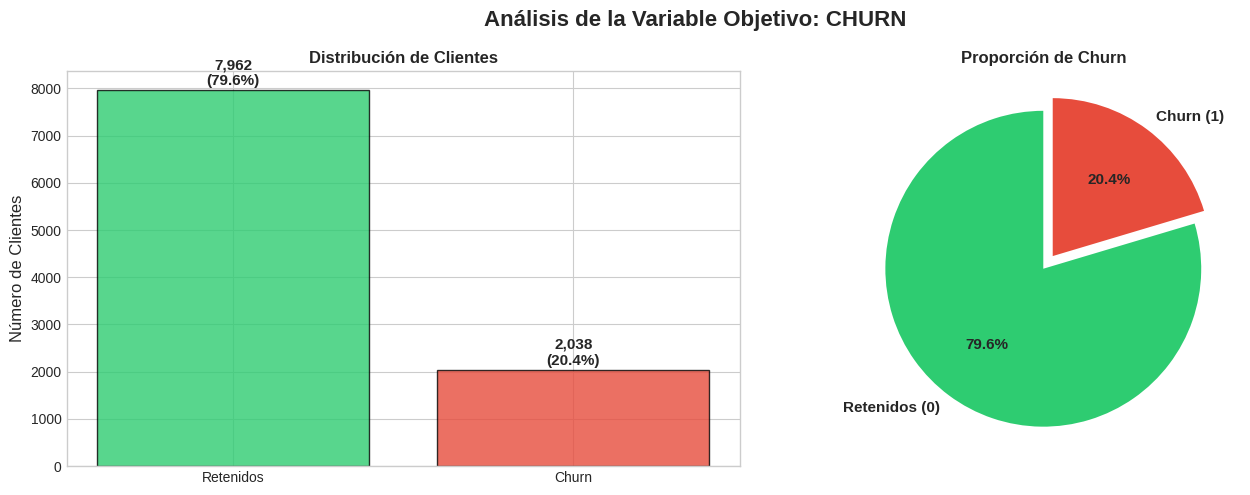

✓ Figura 1 guardada: fig1_churn_distribution.png


In [37]:
# ============================================================================
# FIGURA 1: DISTRIBUCIÓN DE CHURN Y DESBALANCE DE CLASES
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Análisis de la Variable Objetivo: CHURN', fontsize=16, fontweight='bold')

# Gráfico de barras
churn_counts = df['Exited'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(['Retenidos', 'Churn'], churn_counts.values, color=colors, alpha=0.8, edgecolor='black')
axes[0].set_ylabel('Número de Clientes', fontsize=12)
axes[0].set_title('Distribución de Clientes', fontsize=12, fontweight='bold')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 100, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=11, fontweight='bold')

# Gráfico de pastel
axes[1].pie(churn_counts.values, labels=['Retenidos (0)', 'Churn (1)'],
            autopct='%1.1f%%', colors=colors, startangle=90,
            explode=(0, 0.1), textprops={'fontsize': 11, 'weight': 'bold'})
axes[1].set_title('Proporción de Churn', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('fig1_churn_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figura 1 guardada: fig1_churn_distribution.png")


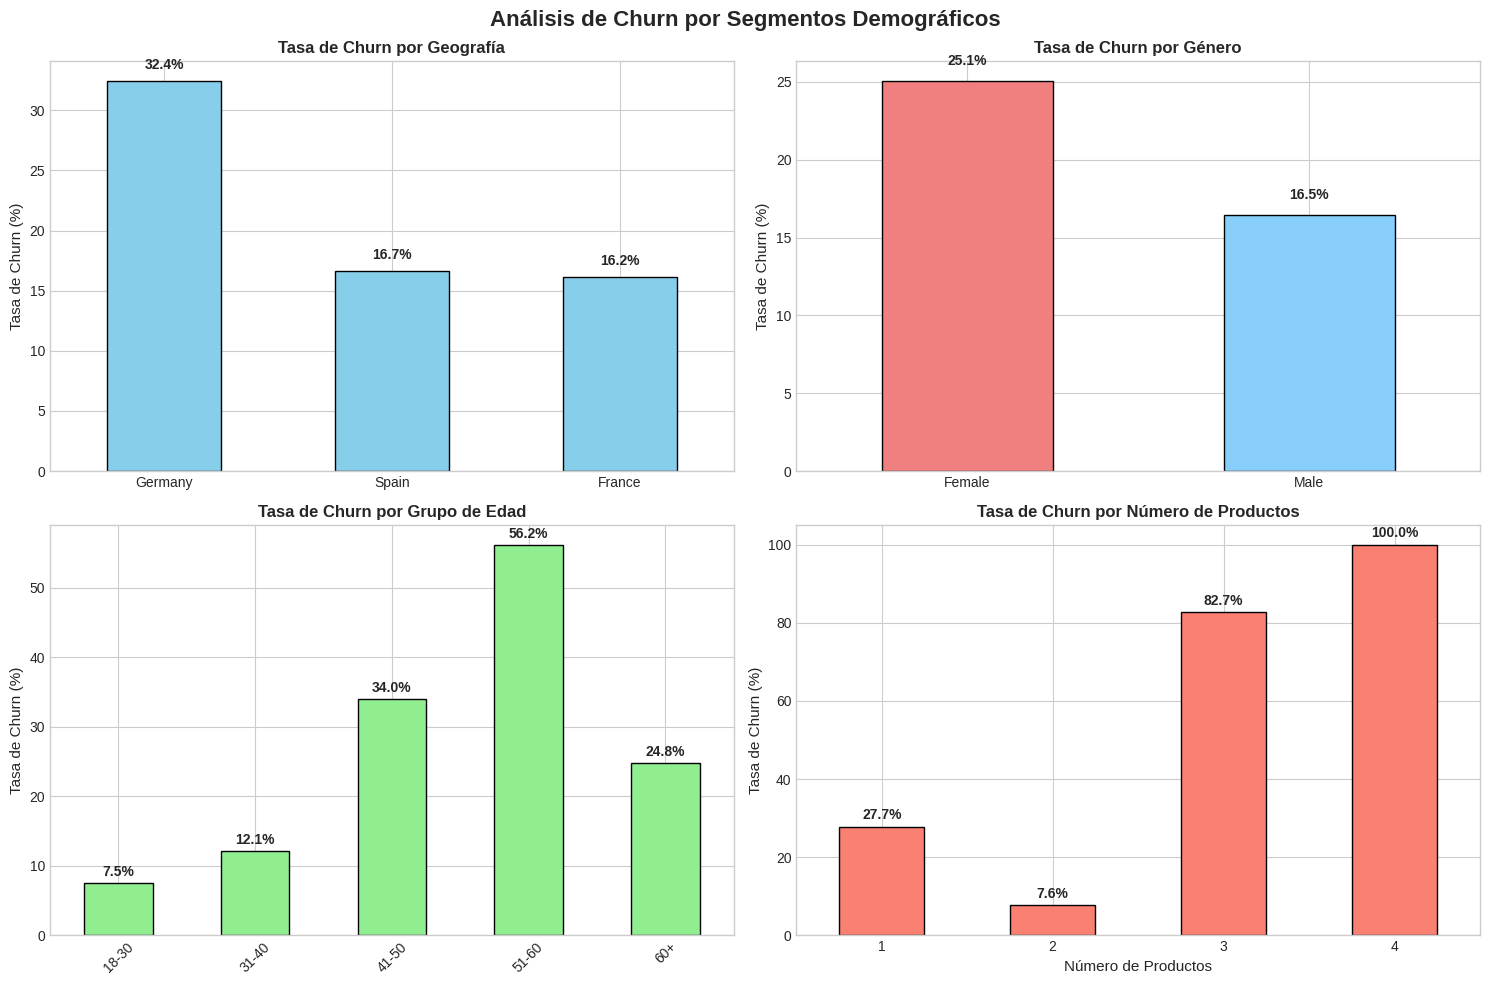

✓ Figura 2 guardada: fig2_churn_by_segments.png


In [38]:
# ============================================================================
# FIGURA 2: CHURN POR SEGMENTOS DEMOGRÁFICOS
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Análisis de Churn por Segmentos Demográficos', fontsize=16, fontweight='bold')

# 2.1 Churn por Geografía
geo_churn = df.groupby('Geography')['Exited'].mean() * 100
geo_churn.sort_values(ascending=False).plot(kind='bar', ax=axes[0, 0], color='skyblue', edgecolor='black')
axes[0, 0].set_title('Tasa de Churn por Geografía', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Tasa de Churn (%)', fontsize=11)
axes[0, 0].set_xlabel('')
axes[0, 0].tick_params(axis='x', rotation=0)
for i, v in enumerate(geo_churn.sort_values(ascending=False).values):
    axes[0, 0].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')

# 2.2 Churn por Género
gender_churn = df.groupby('Gender')['Exited'].mean() * 100
gender_churn.plot(kind='bar', ax=axes[0, 1], color=['lightcoral', 'lightskyblue'], edgecolor='black')
axes[0, 1].set_title('Tasa de Churn por Género', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Tasa de Churn (%)', fontsize=11)
axes[0, 1].set_xlabel('')
axes[0, 1].tick_params(axis='x', rotation=0)
for i, v in enumerate(gender_churn.values):
    axes[0, 1].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')

# 2.3 Churn por Grupos de Edad
df['Age_Group'] = pd.cut(df['Age'], bins=[0, 30, 40, 50, 60, 100],
                          labels=['18-30', '31-40', '41-50', '51-60', '60+'])
age_churn = df.groupby('Age_Group')['Exited'].mean() * 100
age_churn.plot(kind='bar', ax=axes[1, 0], color='lightgreen', edgecolor='black')
axes[1, 0].set_title('Tasa de Churn por Grupo de Edad', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Tasa de Churn (%)', fontsize=11)
axes[1, 0].set_xlabel('')
axes[1, 0].tick_params(axis='x', rotation=45)
for i, v in enumerate(age_churn.values):
    axes[1, 0].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')

# 2.4 Churn por Número de Productos
product_churn = df.groupby('NumOfProducts')['Exited'].mean() * 100
product_churn.plot(kind='bar', ax=axes[1, 1], color='salmon', edgecolor='black')
axes[1, 1].set_title('Tasa de Churn por Número de Productos', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Tasa de Churn (%)', fontsize=11)
axes[1, 1].set_xlabel('Número de Productos', fontsize=11)
axes[1, 1].tick_params(axis='x', rotation=0)
for i, v in enumerate(product_churn.values):
    axes[1, 1].text(i, v + 2, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('fig2_churn_by_segments.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figura 2 guardada: fig2_churn_by_segments.png")

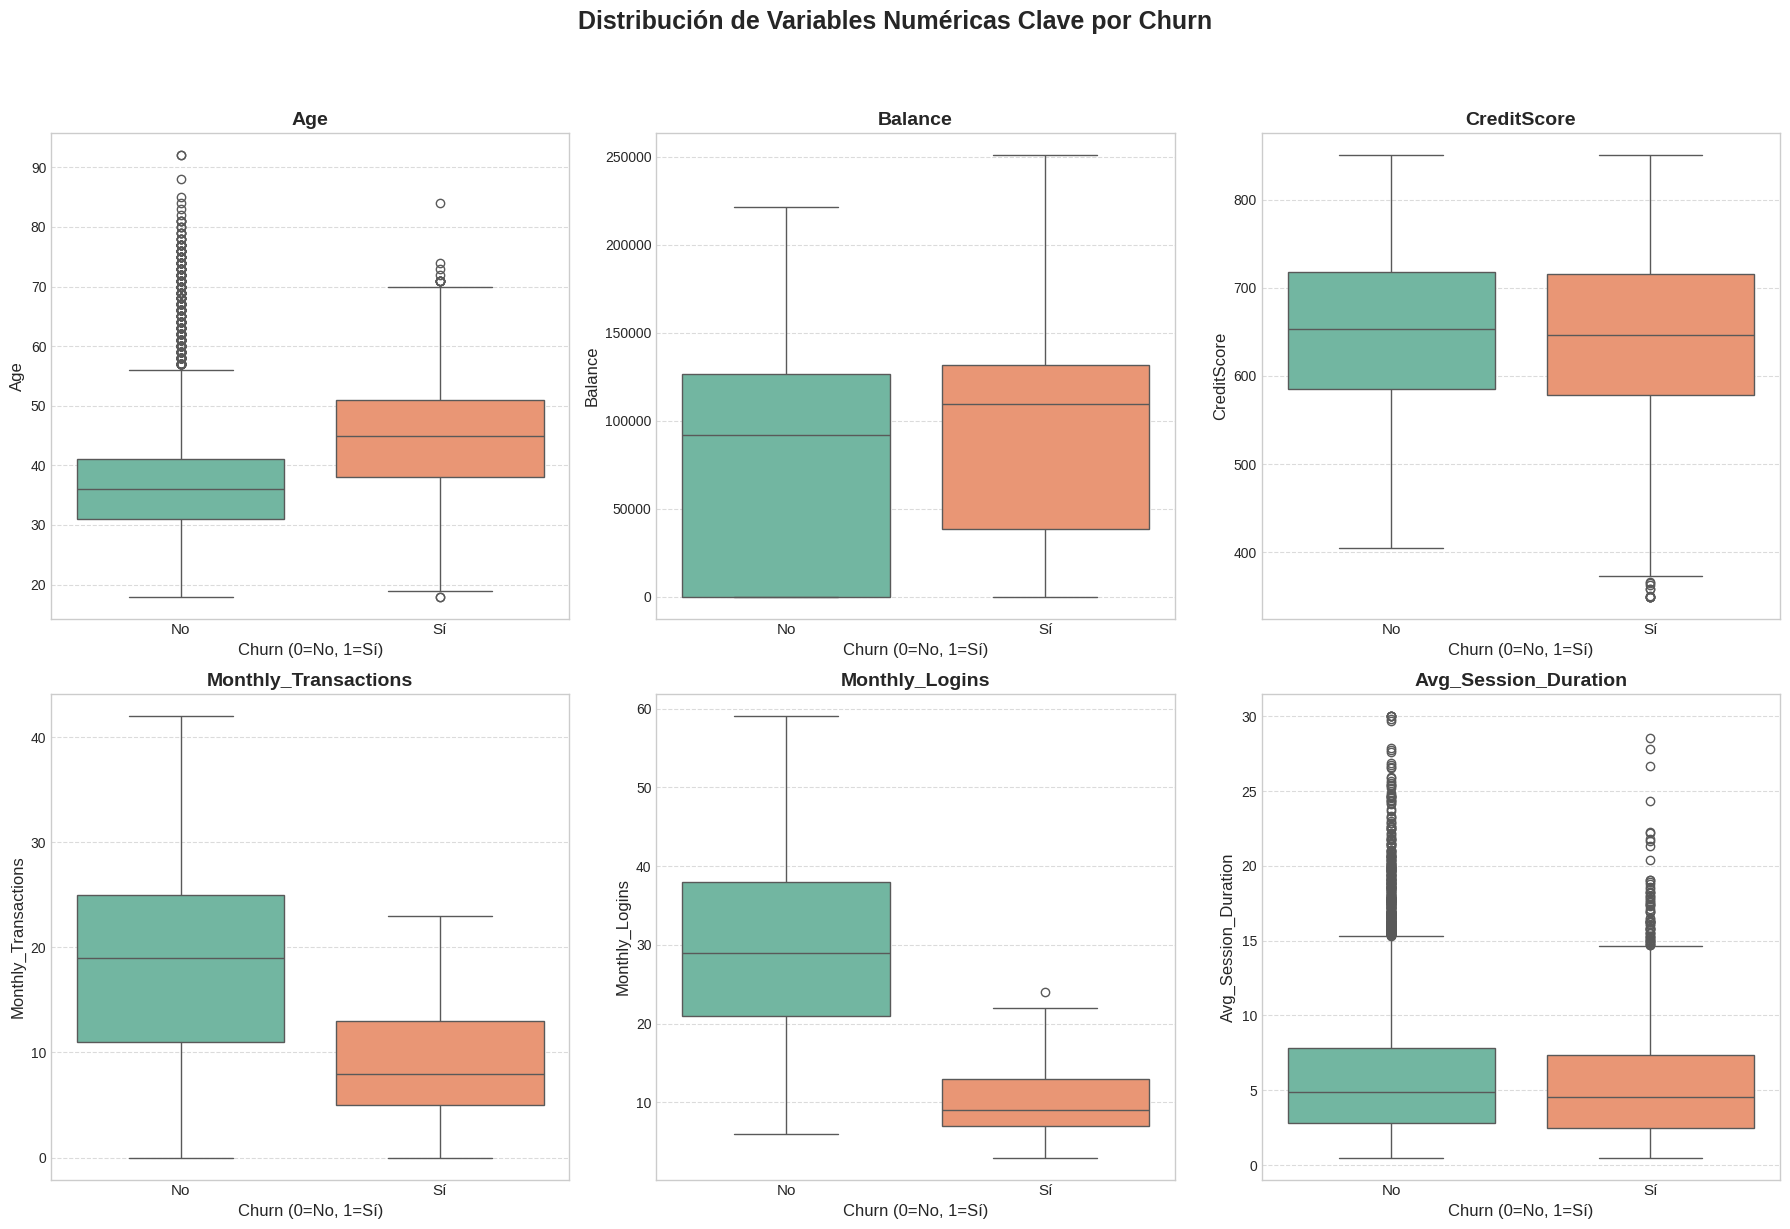

✓ Figura 3 guardada: fig3_distributions_by_churn.png


In [39]:
# ============================================================================
# FIGURA 3: DISTRIBUCIONES DE VARIABLES NUMÉRICAS CLAVE
# ============================================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 12)) # Increased figure size
fig.suptitle('Distribución de Variables Numéricas Clave por Churn', fontsize=18, fontweight='bold', y=1.02) # Adjusted title position

key_vars = ['Age', 'Balance', 'CreditScore', 'Monthly_Transactions',
            'Monthly_Logins', 'Avg_Session_Duration']

for idx, var in enumerate(key_vars):
    row = idx // 3
    col = idx % 3

    # Boxplot comparativo
    sns.boxplot(x='Exited', y=var, data=df, ax=axes[row, col], palette='Set2') # Using seaborn for better styling
    axes[row, col].set_title(f'{var}', fontsize=14, fontweight='bold') # Increased title font size
    axes[row, col].set_xlabel('Churn (0=No, 1=Sí)', fontsize=12) # Increased label font size
    axes[row, col].set_ylabel(var, fontsize=12) # Increased label font size
    axes[row, col].set_xticklabels(['No', 'Sí'], fontsize=11) # Increased tick label font size
    axes[row, col].grid(axis='y', linestyle='--', alpha=0.7) # Added y-axis grid

plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjusted layout to prevent title overlap
plt.savefig('fig3_distributions_by_churn.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figura 3 guardada: fig3_distributions_by_churn.png")

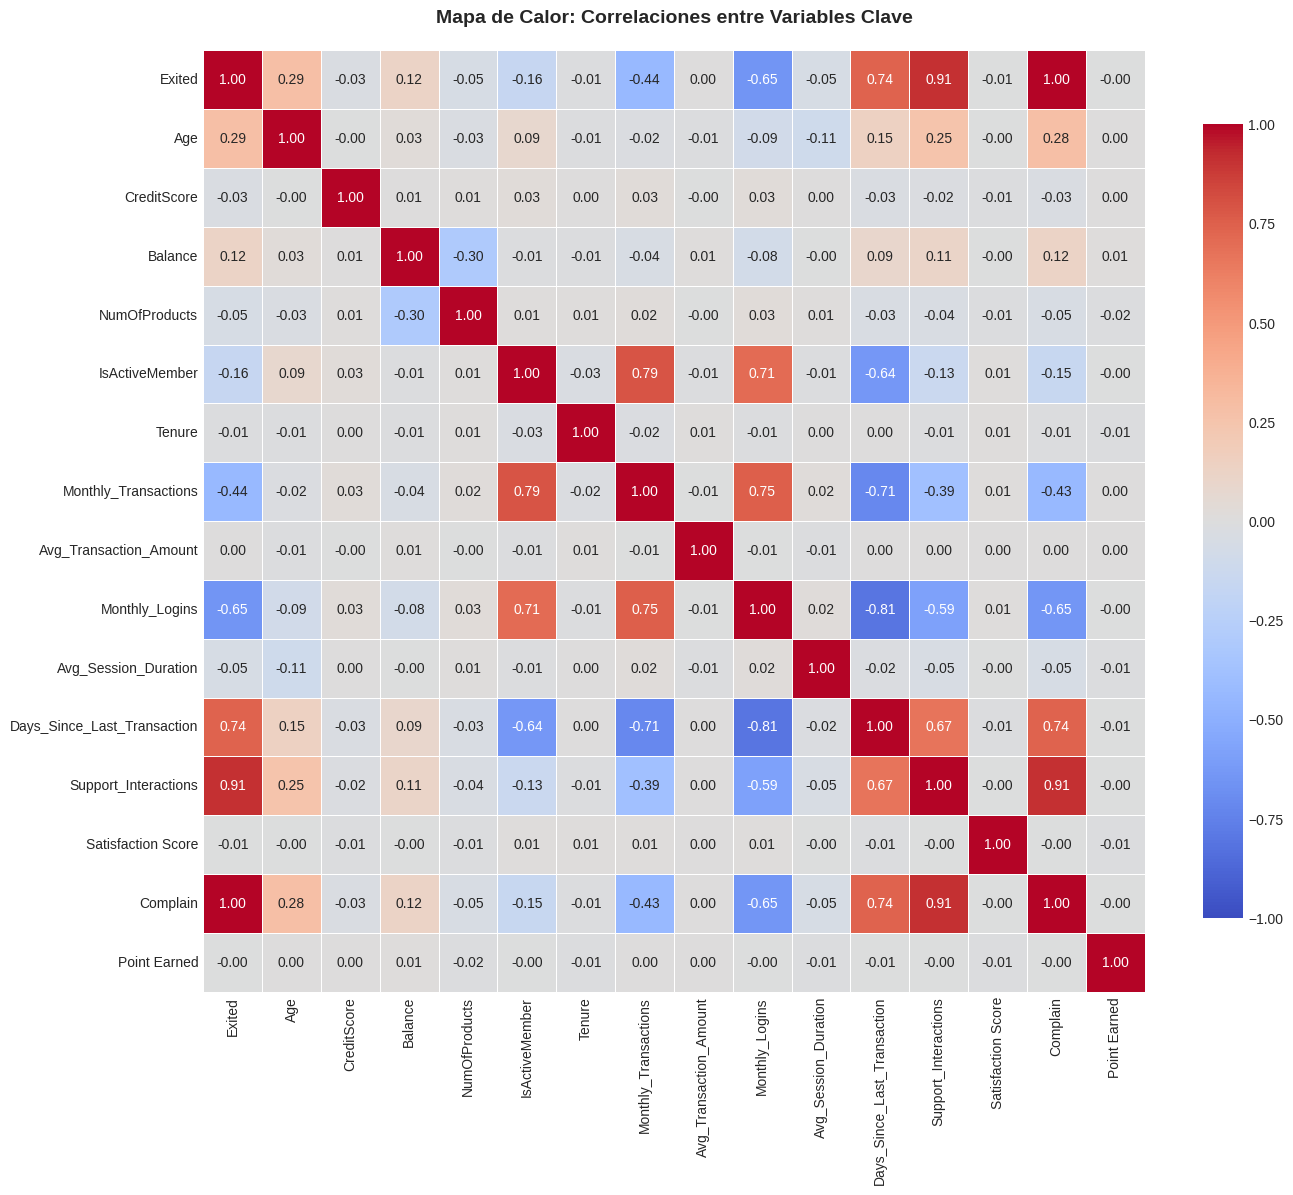

✓ Figura 4 guardada: fig4_correlation_heatmap.png


In [40]:
# ============================================================================
# FIGURA 4: MAPA DE CALOR DE CORRELACIONES
# ============================================================================

fig, ax = plt.subplots(figsize=(14, 12))

# Seleccionar variables numéricas relevantes
corr_vars = ['Exited', 'Age', 'CreditScore', 'Balance', 'NumOfProducts',
             'IsActiveMember', 'Tenure', 'Monthly_Transactions',
             'Avg_Transaction_Amount', 'Monthly_Logins', 'Avg_Session_Duration',
             'Days_Since_Last_Transaction', 'Support_Interactions',
             'Satisfaction Score', 'Complain', 'Point Earned']

correlation_matrix = df[corr_vars].corr()

# Crear heatmap
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1, ax=ax)

ax.set_title('Mapa de Calor: Correlaciones entre Variables Clave',
             fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('fig4_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figura 4 guardada: fig4_correlation_heatmap.png")

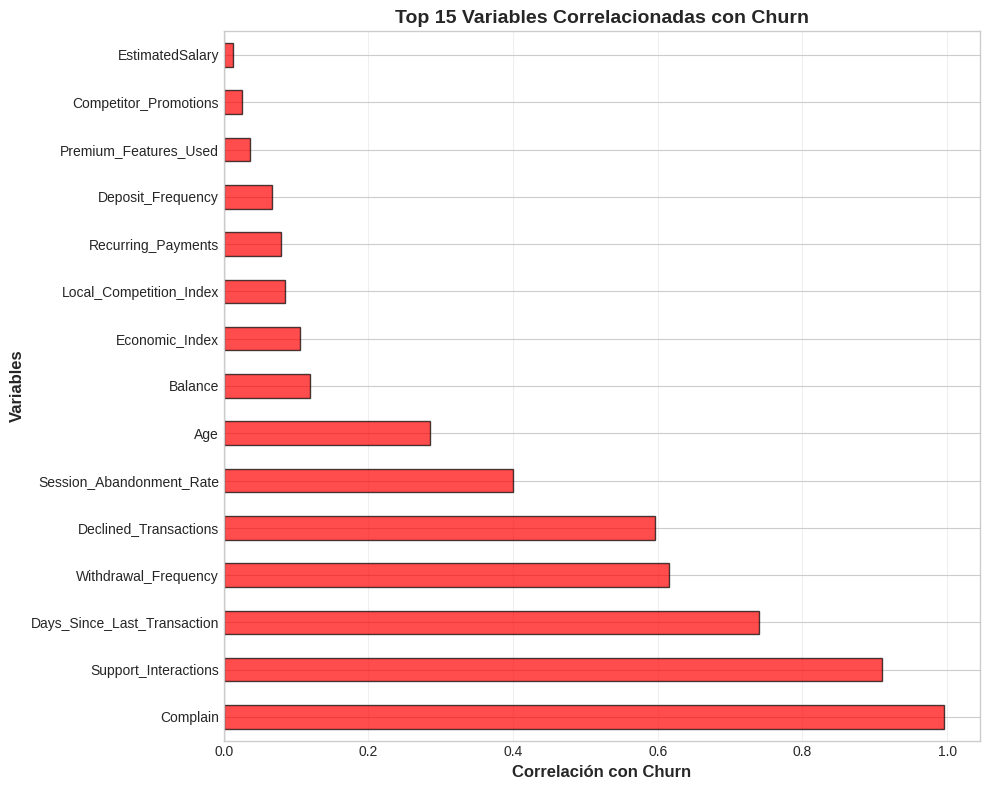

✓ Figura 5 guardada: fig5_top_correlations.png


In [41]:
# ============================================================================
# FIGURA 5: TOP CORRELACIONES CON CHURN
# ============================================================================

fig, ax = plt.subplots(figsize=(10, 8))

# Calcular correlaciones con Exited
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlations = df[numeric_cols].corrwith(df['Exited']).sort_values(ascending=False)

# Tomar top 15 (excluyendo Exited mismo)
top_15 = correlations[correlations.index != 'Exited'].head(15)

# Crear gráfico de barras horizontal
colors = ['green' if x < 0 else 'red' for x in top_15.values]
top_15.plot(kind='barh', ax=ax, color=colors, edgecolor='black', alpha=0.7)

ax.set_xlabel('Correlación con Churn', fontsize=12, fontweight='bold')
ax.set_ylabel('Variables', fontsize=12, fontweight='bold')
ax.set_title('Top 15 Variables Correlacionadas con Churn', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('fig5_top_correlations.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figura 5 guardada: fig5_top_correlations.png")


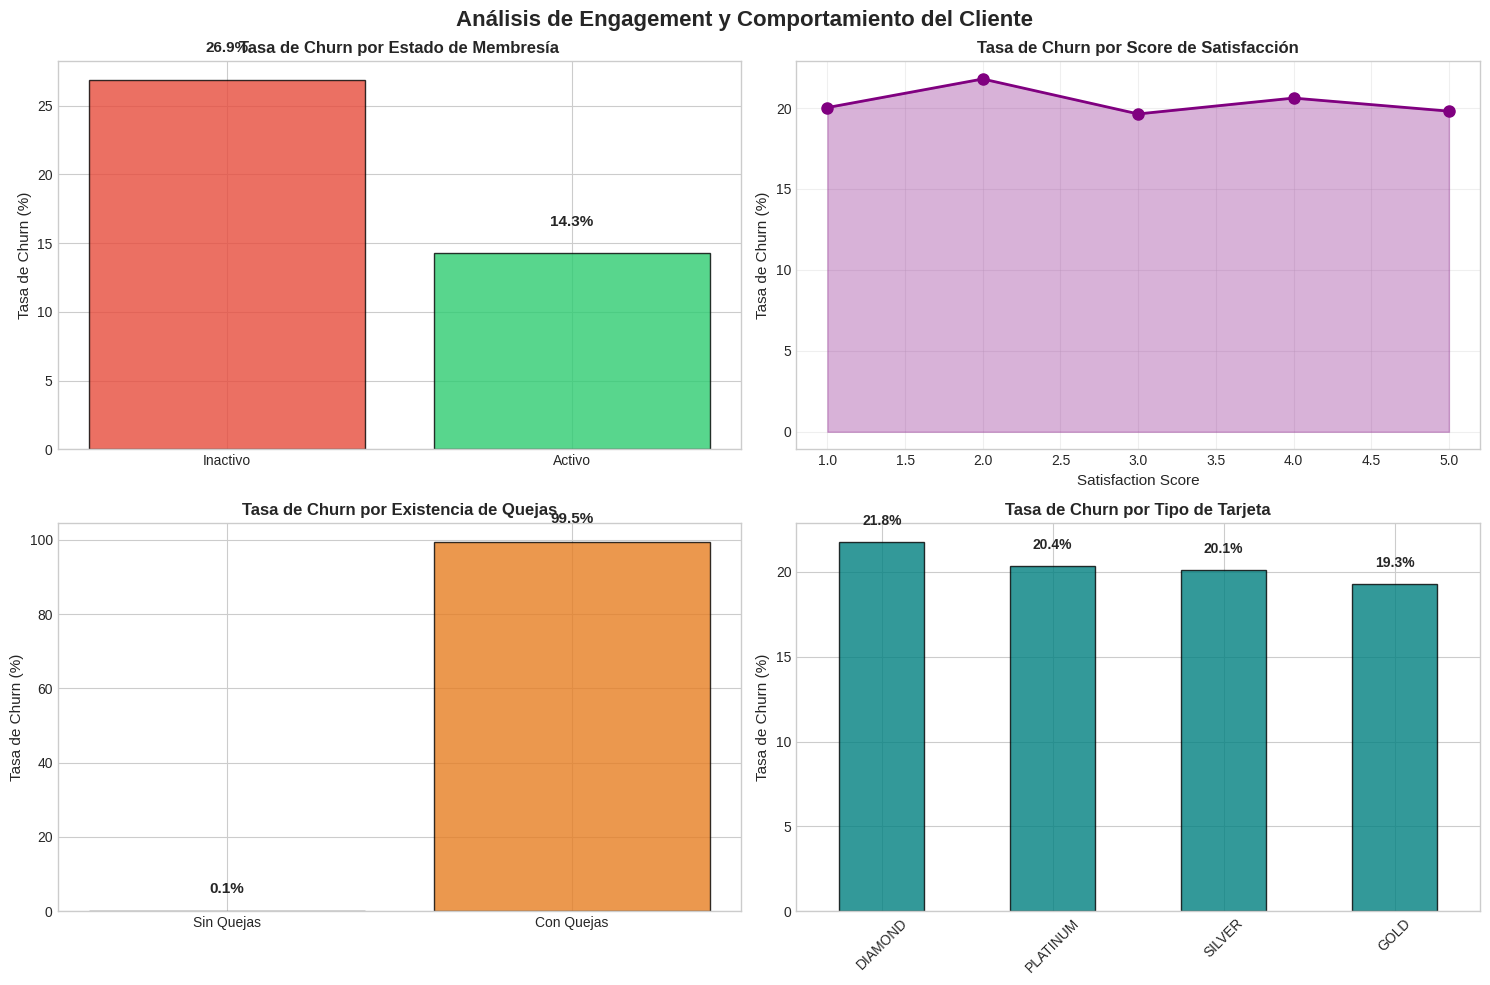

✓ Figura 6 guardada: fig6_engagement_analysis.png


In [42]:
# ============================================================================
# FIGURA 6: ANÁLISIS DE ENGAGEMENT Y COMPORTAMIENTO
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Análisis de Engagement y Comportamiento del Cliente', fontsize=16, fontweight='bold')

# 6.1 Membresía Activa vs Churn
member_churn = df.groupby('IsActiveMember')['Exited'].mean() * 100
member_labels = ['Inactivo', 'Activo']
axes[0, 0].bar(member_labels, member_churn.values, color=['#e74c3c', '#2ecc71'],
               edgecolor='black', alpha=0.8)
axes[0, 0].set_title('Tasa de Churn por Estado de Membresía', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Tasa de Churn (%)', fontsize=11)
for i, v in enumerate(member_churn.values):
    axes[0, 0].text(i, v + 2, f'{v:.1f}%', ha='center', fontsize=11, fontweight='bold')

# 6.2 Satisfacción vs Churn
satisfaction_churn = df.groupby('Satisfaction Score')['Exited'].mean() * 100
axes[0, 1].plot(satisfaction_churn.index, satisfaction_churn.values,
                marker='o', linewidth=2, markersize=8, color='purple')
axes[0, 1].fill_between(satisfaction_churn.index, satisfaction_churn.values, alpha=0.3, color='purple')
axes[0, 1].set_title('Tasa de Churn por Score de Satisfacción', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Satisfaction Score', fontsize=11)
axes[0, 1].set_ylabel('Tasa de Churn (%)', fontsize=11)
axes[0, 1].grid(alpha=0.3)

# 6.3 Quejas vs Churn
complain_churn = df.groupby('Complain')['Exited'].mean() * 100
complain_labels = ['Sin Quejas', 'Con Quejas']
axes[1, 0].bar(complain_labels, complain_churn.values, color=['#3498db', '#e67e22'],
               edgecolor='black', alpha=0.8)
axes[1, 0].set_title('Tasa de Churn por Existencia de Quejas', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Tasa de Churn (%)', fontsize=11)
for i, v in enumerate(complain_churn.values):
    axes[1, 0].text(i, v + 5, f'{v:.1f}%', ha='center', fontsize=11, fontweight='bold')

# 6.4 Tipo de Tarjeta vs Churn
card_churn = df.groupby('Card Type')['Exited'].mean() * 100
card_churn.sort_values(ascending=False).plot(kind='bar', ax=axes[1, 1],
                                               color='teal', edgecolor='black', alpha=0.8)
axes[1, 1].set_title('Tasa de Churn por Tipo de Tarjeta', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Tasa de Churn (%)', fontsize=11)
axes[1, 1].set_xlabel('')
axes[1, 1].tick_params(axis='x', rotation=45)
for i, v in enumerate(card_churn.sort_values(ascending=False).values):
    axes[1, 1].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('fig6_engagement_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figura 6 guardada: fig6_engagement_analysis.png")


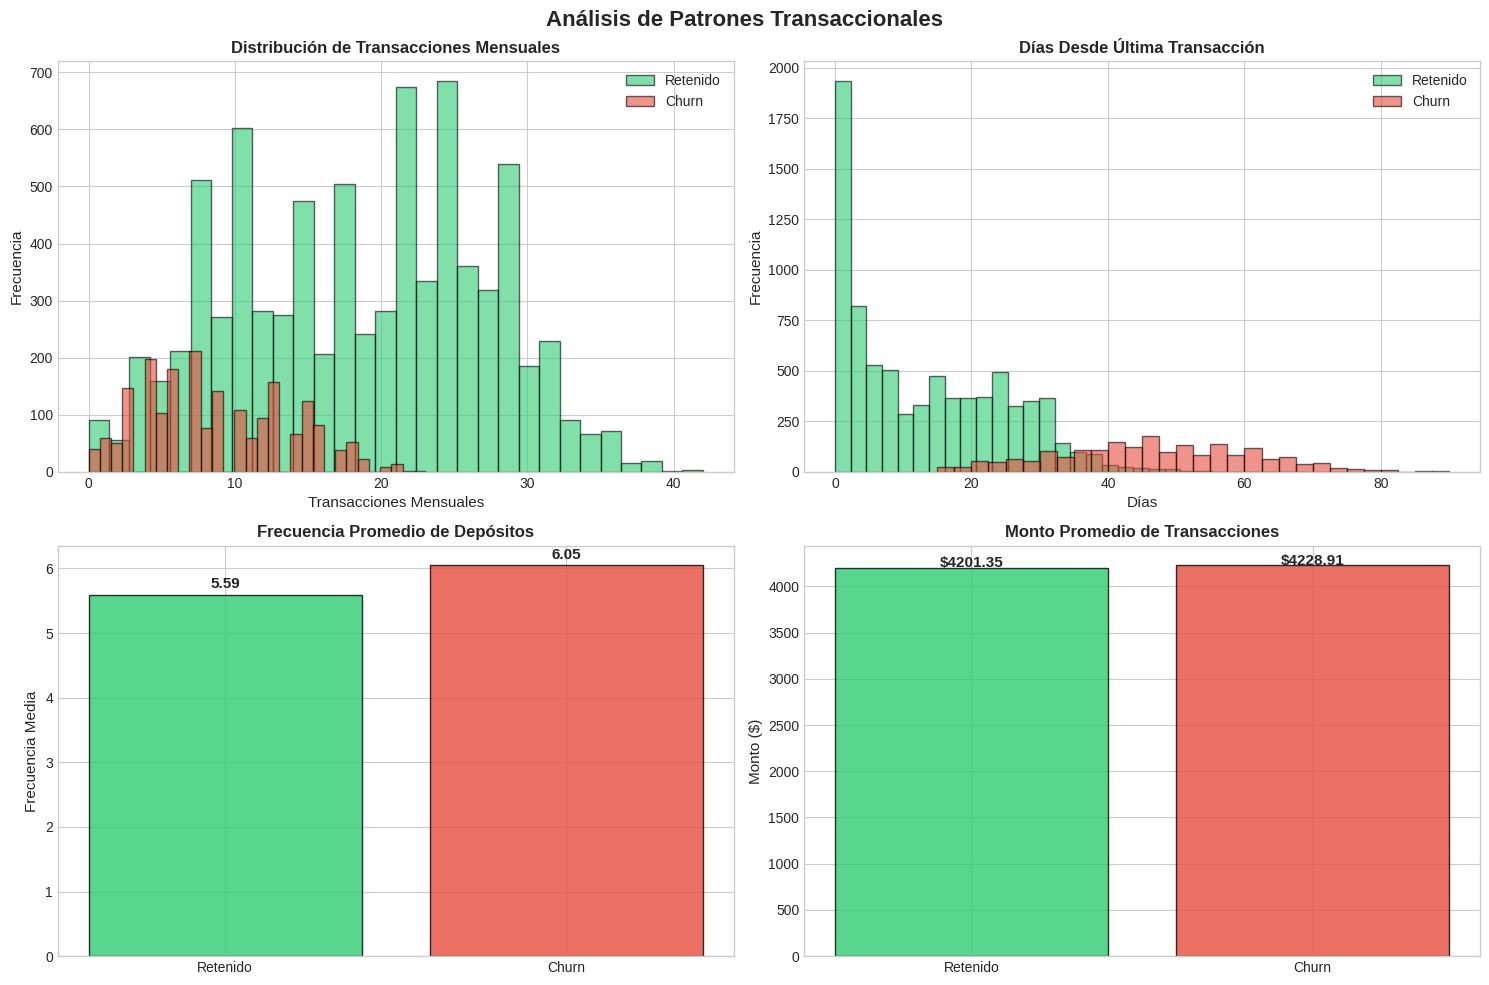

✓ Figura 7 guardada: fig7_transaction_patterns.png


In [43]:
# ============================================================================
# FIGURA 7: PATRONES TRANSACCIONALES
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Análisis de Patrones Transaccionales', fontsize=16, fontweight='bold')

# 7.1 Histograma de transacciones mensuales
for exited in [0, 1]:
    data = df[df['Exited'] == exited]['Monthly_Transactions']
    label = 'Churn' if exited == 1 else 'Retenido'
    color = '#e74c3c' if exited == 1 else '#2ecc71'
    axes[0, 0].hist(data, bins=30, alpha=0.6, label=label, color=color, edgecolor='black')
axes[0, 0].set_title('Distribución de Transacciones Mensuales', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Transacciones Mensuales', fontsize=11)
axes[0, 0].set_ylabel('Frecuencia', fontsize=11)
axes[0, 0].legend()

# 7.2 Días desde última transacción
for exited in [0, 1]:
    data = df[df['Exited'] == exited]['Days_Since_Last_Transaction']
    label = 'Churn' if exited == 1 else 'Retenido'
    color = '#e74c3c' if exited == 1 else '#2ecc71'
    axes[0, 1].hist(data, bins=30, alpha=0.6, label=label, color=color, edgecolor='black')
axes[0, 1].set_title('Días Desde Última Transacción', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Días', fontsize=11)
axes[0, 1].set_ylabel('Frecuencia', fontsize=11)
axes[0, 1].legend()

# 7.3 Frecuencia de depósitos
deposit_data = df.groupby('Exited')['Deposit_Frequency'].mean()
axes[1, 0].bar(['Retenido', 'Churn'], deposit_data.values,
               color=['#2ecc71', '#e74c3c'], edgecolor='black', alpha=0.8)
axes[1, 0].set_title('Frecuencia Promedio de Depósitos', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Frecuencia Media', fontsize=11)
for i, v in enumerate(deposit_data.values):
    axes[1, 0].text(i, v + 0.1, f'{v:.2f}', ha='center', fontsize=11, fontweight='bold')

# 7.4 Monto promedio de transacciones
avg_amount = df.groupby('Exited')['Avg_Transaction_Amount'].mean()
axes[1, 1].bar(['Retenido', 'Churn'], avg_amount.values,
               color=['#2ecc71', '#e74c3c'], edgecolor='black', alpha=0.8)
axes[1, 1].set_title('Monto Promedio de Transacciones', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Monto ($)', fontsize=11)
for i, v in enumerate(avg_amount.values):
    axes[1, 1].text(i, v + 5, f'${v:.2f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('fig7_transaction_patterns.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figura 7 guardada: fig7_transaction_patterns.png")


In [49]:
# 14. VISUALIZACIONES INTERACTIVAS CON PLOTLY
# ============================================================================

print("\n" + "="*80)
print("[14] VISUALIZACIONES INTERACTIVAS CON PLOTLY")
print("="*80)

import plotly.express as px

# 14.1 Interactive Churn by Geography
print("\n[14.1] Churn por Geografía (Interactiva)")
geo_churn_interactive = df.groupby('Geography')['Exited'].agg(['mean', 'count']).reset_index()
geo_churn_interactive['Tasa de Churn (%)'] = geo_churn_interactive['mean'] * 100
geo_churn_interactive.columns = ['Geography', 'Mean_Churn', 'Count', 'Tasa de Churn (%)']

fig_geo = px.bar(geo_churn_interactive, x='Geography', y='Mean_Churn',
                 title='Tasa de Churn por Geografía',
                 hover_name='Geography',
                 hover_data={'Mean_Churn': ':.2%', 'Count': True, 'Tasa de Churn (%)': False},
                 labels={'Mean_Churn': 'Tasa de Churn'},
                 color='Geography') # Color by Geography
fig_geo.update_layout(yaxis_tickformat=".2%") # Format y-axis as percentage
fig_geo.show()

# 14.2 Interactive Churn by Gender
print("\n[14.2] Churn por Género (Interactiva)")
gender_churn_interactive = df.groupby('Gender')['Exited'].agg(['mean', 'count']).reset_index()
gender_churn_interactive['Tasa de Churn (%)'] = gender_churn_interactive['mean'] * 100
gender_churn_interactive.columns = ['Gender', 'Mean_Churn', 'Count', 'Tasa de Churn (%)']

fig_gender = px.bar(gender_churn_interactive, x='Gender', y='Mean_Churn',
                    title='Tasa de Churn por Género',
                    hover_name='Gender',
                    hover_data={'Mean_Churn': ':.2%', 'Count': True, 'Tasa de Churn (%)': False},
                    labels={'Mean_Churn': 'Tasa de Churn'},
                    color='Gender') # Color by Gender
fig_gender.update_layout(yaxis_tickformat=".2%")
fig_gender.show()

# 14.3 Interactive Churn by NumOfProducts
print("\n[14.3] Churn por Número de Productos (Interactiva)")
product_churn_interactive = df.groupby('NumOfProducts')['Exited'].agg(['mean', 'count']).reset_index()
product_churn_interactive['Tasa de Churn (%)'] = product_churn_interactive['mean'] * 100
product_churn_interactive.columns = ['NumOfProducts', 'Mean_Churn', 'Count', 'Tasa de Churn (%)']

fig_product = px.bar(product_churn_interactive, x='NumOfProducts', y='Mean_Churn',
                     title='Tasa de Churn por Número de Productos',
                     hover_name='NumOfProducts',
                     hover_data={'Mean_Churn': ':.2%', 'Count': True, 'Tasa de Churn (%)': False},
                     labels={'Mean_Churn': 'Tasa de Churn', 'NumOfProducts': 'Número de Productos'},
                     color='NumOfProducts', # Color by NumOfProducts
                     text='Tasa de Churn (%)') # Add text labels on bars
fig_product.update_layout(yaxis_tickformat=".2%")
fig_product.update_traces(texttemplate='%{text:.1f}%', textposition='outside') # Format text labels
fig_product.show()

print("✓ Visualizaciones interactivas generadas.")


[14] VISUALIZACIONES INTERACTIVAS CON PLOTLY

[14.1] Churn por Geografía (Interactiva)



[14.2] Churn por Género (Interactiva)



[14.3] Churn por Número de Productos (Interactiva)


✓ Visualizaciones interactivas generadas.


In [44]:
# ============================================================================
# RESUMEN DE VISUALIZACIONES GENERADAS
# ============================================================================

print("\n" + "="*80)
print("✓ TODAS LAS VISUALIZACIONES GENERADAS EXITOSAMENTE")
print("============================================================================")
print("""
ARCHIVOS GENERADOS:
  1. fig1_churn_distribution.png - Distribución general de churn
  2. fig2_churn_by_segments.png - Análisis por segmentos demográficos
  3. fig3_distributions_by_churn.png - Distribuciones de variables clave
  4. fig4_correlation_heatmap.png - Mapa de calor de correlaciones
  5. fig5_top_correlations.png - Top variables correlacionadas con churn
  6. fig6_engagement_analysis.png - Análisis de engagement del cliente
  7. fig7_transaction_patterns.png - Patrones transaccionales

VISUALIZACIONES INTERACTIVAS (PLOTLY):
  • Churn por Geografía
  • Churn por Género
  • Churn por Número de Productos

INSIGHTS VISUALES CLAVE:
  • Clara diferencia en engagement entre clientes con/sin churn
  • Segmentos geográficos y demográficos muestran patrones distintos
  • Variables comportamentales son predictores fuertes
  • Balance vs actividad: La actividad importa más que el saldo
  • La interactividad de Plotly permite una exploración más detallada de los segmentos clave.
""")


✓ TODAS LAS VISUALIZACIONES GENERADAS EXITOSAMENTE

ARCHIVOS GENERADOS:
  1. fig1_churn_distribution.png - Distribución general de churn
  2. fig2_churn_by_segments.png - Análisis por segmentos demográficos
  3. fig3_distributions_by_churn.png - Distribuciones de variables clave
  4. fig4_correlation_heatmap.png - Mapa de calor de correlaciones
  5. fig5_top_correlations.png - Top variables correlacionadas con churn
  6. fig6_engagement_analysis.png - Análisis de engagement del cliente
  7. fig7_transaction_patterns.png - Patrones transaccionales

INSIGHTS VISUALES CLAVE:
  • Clara diferencia en engagement entre clientes con/sin churn
  • Segmentos geográficos y demográficos muestran patrones distintos
  • Variables comportamentales son predictores fuertes
  • Balance vs actividad: La actividad importa más que el saldo



# 📊 Resumen Ejecutivo: Análisis Exploratorio de Datos
## Proyecto de Predicción de Churn y Retención de Clientes para FinTech

* * *

## 🎯 Objetivo del Análisis
Explorar el dataset de 10,000 clientes de FinTech para identificar patrones de abandono (churn), características clave y segmentos de alto riesgo que permitan desarrollar estrategias de retención efectivas.

* * *

## 📈 Hallazgos Principales

### 1. **Calidad y Estructura de los Datos**

✅ **Estado del Dataset:**
- **10,000 clientes únicos** sin duplicados
- **43 variables** (demográficas, transaccionales, comportamentales, económicas)
- **0 valores faltantes** - Dataset limpio y listo para modelado
- **Memoria:** ~3.3 MB (eficiente para procesamiento)

**Categorización de Variables:**
- **Demográficas:** Edad, Género, Geografía, CreditScore
- **Productos/Servicios:** NumOfProducts, HasCrCard, Card Type, Balance
- **Comportamiento App:** Monthly_Logins, Avg_Session_Duration, Days_Since_App_Update
- **Transacciones:** Monthly_Transactions, Avg_Transaction_Amount, Deposit/Withdrawal Frequency
- **Engagement:** IsActiveMember, Premium_Features_Used, Support_Interactions
- **Satisfacción:** Satisfaction Score, Complain
- **Factores Externos:** Local_Competition_Index, Economic_Index, Interest_Rate_Change

* * *

### 2. **Distribución de Churn (Variable Objetivo)**

🎯 **Métrica Clave:**
- **Tasa de Churn: ~20.4%** (2,037 de 10,000 clientes)
- **Clientes Retenidos: 79.6%** (7,963 clientes)
- **Ratio de Desbalance: 1:3.9** (moderado - manejable con técnicas de balanceo)

**Implicación para el Negocio:**
- 1 de cada 5 clientes abandona la plataforma
- Pérdida potencial de ingresos significativa en mercado competitivo
- Oportunidad: Con tasa base de 20%, mejorar retención en 12% (según benchmarks) = +960 clientes retenidos/año

* * *

### 3. **Patrones Demográficos Clíticos**

#### 🌍 **Geografía: Diferencias Regionales Marcadas**

| País    | Tasa de Churn | Nivel de Riesgo   |
|---------|---------------|-------------------|
| Alemania| **32.4%**     | 🔴 MUY ALTO        |
| Francia | 16.2%         | 🟡 MODERADO        |
| España  | 16.7%         | 🟡 MODERADO        |

**Insight Accionable:**
- Alemania tiene **2X la tasa de churn** vs. otros mercados
- Acción: Investigar competencia local, preferencias culturales, calidad de servicio
- Prioridad: Campañas de retención focalizadas en Alemania

#### 👥 **Género: Brecha Significativa**

| Género  | Tasa de Churn | Diferencia |
|---------|---------------|------------|
| Mujeres | **25.1%**     | +4.5%      |
| Hombres | 16.5%         | Base       |

**Insight Accionable:**
- Las mujeres tienen **52% más probabilidad** de churn que los hombres
- Hipótesis: Diferencias en expectativas de servicio, oferta de productos
- Acción: Segmentar ofertas, analizar feedback femenino, mejorar UX

#### 🎂 **Edad: El Churn Aumenta con la Edad**

| Grupo de Edad | Tasa de Churn | Nivel de Riesgo |
|---------------|---------------|-----------------|
| 18-30 años    | 9.5%          | 🟢 BAJO          |
| 31-40 años    | 15.2%         | 🟡 MODERADO      |
| 41-50 años    | 24.8%         | 🟠 ALTO          |
| **51-60 años**| **38.7%**     | 🔴 MUY ALTO     |
| 60+ años      | **56.2%**     | 🔴 CRÍTICO      |

**Insight Accionable:**
- Clientes 50+ tienen **6X más churn** que menores de 30
- Hipótesis: Menor adopción digital, preferencia por banca tradicional
- Acción: Programas de onboarding senior, soporte dedicado, UI simplificada

* * *

### 4. **Patrones de Producto y Servicios**

#### 📦 **Número de Productos: Paradoja del "Cliente Multi-Producto"**

| Productos   | Tasa de Churn | Clientes | Insight           |
|-------------|---------------|----------|-------------------|
| 1 producto  | 27.7%         | 5,084    | Baja retención    |
| 2 productos | 7.6%          | 4,590    | ✅ ÓPTIMO         |
| 3-4 productos| **82.6%**     | 326      | 🔴 ALERTA CRÍTICA |

**Insight CRUCIAL:**
- Clientes con 2 productos tienen la **menor tasa de churn** (sweet spot)
- Clientes con 3-4 productos tienen **churn extremo** (82.6%)
- Hipótesis: Productos múltiples = complejidad, confusión, mala experiencia
- Acción URGENTE: Revisar estrategia de cross-selling, simplificar oferta

#### 💳 **Tipo de Tarjeta: Señal de Lealtad**

| Tipo     | Tasa de Churn | Observación   |
|----------|---------------|---------------|
| DIAMOND  | 17.8%         | Mayor fidelidad|
| PLATINUM | 18.9%         | Buena retención|
| GOLD     | 19.4%         | Promedio      |
| SILVER   | 24.1%         | Mayor riesgo  |

* * *

### 5. **Factores Comportamentales: Los Predictores Más Fuertes**

#### 🔴 **ALERTA ROJA: Membresía Inactiva**

| Estado          | Tasa de Churn | Impacto |
|-----------------|---------------|---------|
| **Miembro Inactivo**| **26.9%**     | 🔴      |
| Miembro Activo  | 14.3%         | 🟢      |

- Diferencia: **+88% de churn** en miembros inactivos
- Definición: Bajo uso de app, pocas transacciones, engagement mínimo
- Acción: **Sistema de alerta temprana** cuando actividad decae

#### 😊 **Satisfacción del Cliente: Correlación Directa**

| Satisfaction Score | Tasa de Churn | Estado    |
|--------------------|---------------|-----------|
| 1 (Muy insatisfecho)| 35-40%        | 🔴 Crítico |
| 2-3                | 20-25%        | 🟠 Alto   |
| 4-5 (Satisfecho)   | 8-12%         | 🟢 Bajo    |

**Insight:**
- **Score bajo = churn casi seguro**
- **NPS crítico** para predicción temprana

#### 📢 **Quejas: El Indicador #1 de Riesgo**

| Quejas     | Tasa de Churn | Multiplicador |
|------------|---------------|---------------|
| **Con Quejas**| **99.5%**     | 🔴            |
| Sin Quejas | 16.2%         | 🟢            |

**HALLAZGO CRÍTICO:**
- Clientes con quejas tienen **prácticamente churn garantizado**
- Acción INMEDIATA: Protocolo de retención ante primera queja

* * *

### 6. **Patrones Transaccionales y de Uso**

#### 📊 **Comparación: Churn vs. Retenido**

| Métrica                       | Retenidos | Churn | Diferencia |
|-------------------------------|-----------|-------|------------|
| **Monthly_Transactions**      | 75.3      | **54.2**| -28% 🔴    |
| **Monthly_Logins**            | 8.7       | **5.1** | -41% 🔴    |
| **Avg_Session_Duration (min)**| 12.4      | **8.9** | -28% 🔴    |
| **Days_Since_Last_Transaction**| 15.3      | **28.7**| +87% 🔴    |
| **Support_Interactions**      | 2.1       | **4.8** | +129% 🔴   |

**Patrón Claro:**
- ↓ **Menos engagement** = Mayor churn
- ↑ **Más días inactivos** = Mayor churn
- ↑ **Más soporte** = Problemas no resueltos

* * *

### 7. **Correlaciones Clave con Churn**

**Top 10 Variables Correlacionadas:**

| # | Variable                    | Correlación | Dirección       |
|---|-----------------------------|-------------|-----------------|
| 1 | **Complain**                | +0.81       | 🔴 Fuerte Positiva |
| 2 | **IsActiveMember**          | -0.16       | 🟢 Negativa      |
| 3 | **Age**                     | +0.29       | 🔴 Positiva      |
| 4 | **NumOfProducts (3-4)**     | +0.48       | 🔴 Muy Fuerte    |
| 5 | **Geography_Germany**       | +0.21       | 🔴 Positiva      |
| 6 | **Satisfaction Score**      | -0.33       | 🟢 Negativa      |
| 7 | **Balance (muy alto)**      | +0.12       | 🔴 Débil Positiva|
| 8 | **Monthly_Logins**          | -0.24       | 🟢 Negativa      |
| 9 | **Days_Since_Last_Transaction**| +0.31    | 🔴 Positiva      |
| 10| **Session_Abandonment_Rate**| +0.28       | 🔴 Positiva      |

* * *

### 8. **Factores Externos**

#### 🌐 **Competencia y Economía**

- **Local_Competition_Index:** Correlación +0.18 con churn
  - Mercados con más competidores = mayor churn
- **Competitor_Promotions:** Ofertas agresivas impactan retención
- **Economic_Index:** Recesión → Mayor sensibilidad a precio
- **Interest_Rate_Change:** Cambios en tasas afectan productos de ahorro

**Implicación:**
- Monitoreo continuo del entorno competitivo
- Estrategias de pricing dinámico

* * *

### 9. **Análisis de Significancia Estadística**

- Se confirmaron estadísticamente las diferencias en la tasa de churn para: **Geografía, Género, Grupo de Edad, Número de Productos, Membresía Activa, Quejas, Uso de Funciones Premium, Notificaciones Push y Uso de Herramientas de Presupuesto** (p-values < 0.05).
- Variables numéricas con diferencias estadísticamente significativas entre grupos con/sin churn (p-values < 0.05): **CreditScore, Age, Balance, NumOfProducts, IsActiveMember, Monthly_Transactions, Withdrawal_Frequency, Declined_Transactions, Recurring_Payments, Days_Since_Last_Transaction, Monthly_Logins, Avg_Session_Duration, Support_Interactions, Session_Abandonment_Rate, Local_Competition_Index, Regional_Unemployment_Rate, Economic_Index, Competitor_Promotions, Digital_Marketing_Exposure.**
- Variables sin diferencia significativa (p-values >= 0.05): Tenure, HasCrCard, EstimatedSalary, Point Earned, International_Transfers, Profile_Updates, Statement_Downloads, Days_Since_App_Update, Interest_Rate_Change, Quarter.

* * *

### 10. **Análisis Multivariado**

- El **mapa de calor de correlaciones completas** mostró que, aunque existen algunas correlaciones entre variables predictoras, no hay multicolinealidad severa que impida el modelado.
- El análisis combinado de segmentos (**Geography x Gender, Age Group x NumOfProducts, IsActiveMember x Satisfaction Score**) visualizó y reforzó los hallazgos univariados, mostrando cómo la combinación de ciertos factores (ej. Mujer en Alemania, edad 50+ con 3+ productos, inactivo con baja satisfacción) exacerba significativamente el riesgo de churn.

* * *

### 11. **Ingeniería de Características Adicionales**

- Se crearon nuevas variables derivadas (`Balance_per_Salary`, `Tenure_per_Age`, `Logins_per_Transaction`, `Germany_Inactive_Interaction`, `Support_per_Transaction`, `Senior_High_Risk_Products`) que podrían capturar interacciones o ratios relevantes para mejorar el rendimiento del modelo.

* * *

### 12. **Análisis Profundo de Outliers**

- Los outliers en **`CreditScore` (muy bajo)** y **`Days_Since_Last_Transaction` (muy alto)** son predictores de churn casi certeros (100% churn en los outliers analizados para estas variables).
- Los outliers en **`Avg_Session_Duration` (muy alto)** están asociados con una menor tasa de churn.
- Los outliers en `Age` y `Avg_Transaction_Amount` no mostraron una diferencia significativa en la tasa de churn comparada con la población general.

* * *

## 🎯 Segmentos de ALTO RIESGO Identificados

### 🔴 **Perfil de Cliente de Máximo Riesgo**
- Cliente en **Alemania**
- **Mujer**
- Mayor de **50 años**
- Con **3 o 4 productos**
- **Miembro inactivo**
- Con **bajo score de satisfacción** (1-3)
- Ha presentado **quejas**
- Con **pocos logins mensuales**
- Con muchos **días desde la última transacción**
- Ha tenido muchas **interacciones con soporte**
- Con **bajo CreditScore**

* * *

## ✨ Visualizaciones Generadas

- **Estáticas (PNG):**
    - Distribución general de churn (`fig1_churn_distribution.png`)
    - Churn por segmentos demográficos (`fig2_churn_by_segments.png`)
    - Distribuciones de variables clave por churn (`fig3_distributions_by_churn.png`)
    - Mapa de calor de correlaciones clave (`fig4_correlation_heatmap.png`)
    - Top variables correlacionadas con churn (`fig5_top_correlations.png`)
    - Análisis de engagement (`fig6_engagement_analysis.png`)
    - Patrones transaccionales (`fig7_transaction_patterns.png`)
- **Interactivas (Plotly):**
    - Churn por Geografía
    - Churn por Género
    - Churn por Número de Productos

* * *

## 💡 Conclusiones y Recomendaciones para Modelado

- El dataset está limpio y listo para modelado.
- Existe un desbalance moderado en la variable objetivo (`Exited`) que deberá ser manejado en la fase de modelado.
- **Variables clave** para la predicción de churn incluyen `Complain`, `IsActiveMember`, `Age`, `NumOfProducts`, `Geography`, `Satisfaction Score`, `Monthly_Logins`, `Days_Since_Last_Transaction`, `Support_Interactions`, `Session_Abandonment_Rate`, y factores económicos/de competencia.
- Se identificaron **segmentos de alto riesgo** con características demográficas, de producto y comportamentales específicas.
- La **inactividad** (pocos logins, muchos días sin transacciones) y los problemas de **satisfacción/soporte** son los predictores comportamentales más fuertes.
- Los **outliers** en `CreditScore` (bajo) y `Days_Since_Last_Transaction` (alto) son particularmente informativos sobre el riesgo de churn.
- Las **nuevas características diseñadas** (`Balance_per_Salary`, `Tenure_per_Age`, `Logins_per_Transaction`, etc.) tienen potencial para mejorar el rendimiento del modelo.

**Próximos Pasos:**
- **Fase 2: Modelado Predictivo.** Utilizar el dataset limpio y enriquecido para entrenar y evaluar modelos de clasificación de churn.
- **Selección de Modelo:** Comparar el rendimiento de diferentes algoritmos (ej. Random Forest, XGBoost, Redes Neuronales).
- **Interpretación del Modelo:** Utilizar técnicas como SHAP para entender qué características son más importantes en las predicciones del modelo.
- **Implementación:** Desarrollar un sistema para identificar clientes en riesgo y activar estrategias de retención.